# HANK model with energy: Estimation and main results

Selma Malmberg & François Langot

January 2025

The aim of this notebook is to solve a HANK model with energy, calibrate it using French data and build counterfactual policies in reaction of the recent energy crisis.

### Table of content
0. [Set up](#0-setup)
1. [Heterogeneous households](#1-HA)
2. [Steady-state](#2-SS)
3. [Dynamics](#3-dynamics)
4. [Estimation](#4-Estim)
5. [Shock decomposition](#5-Shock)
6. [Uncertainty](#6-Lucas)
7. [Scenario](#7-Scenario)
8. [General equilibrium effects](#9-GE)

<a id="0-setup"></a>
## 0 Set up

In [1]:
# Python libraries
import numpy as np
import matplotlib.pyplot as plt
from datetime import date 
import pandas as pd
from scipy.stats import beta, invgamma, norm
import statsmodels.api as sm
import scipy.optimize as opt
import string

In [2]:
# Auclert et al's toolbox
import sequence_jacobian as ssj

In [3]:
from TOOLS.Auclert_Toolbox.plots import plot_impulses
from TOOLS.Auclert_Toolbox.routines import back_out_shocks

In [4]:
# Selma's codes
import TOOLS.utilities as util
import TOOLS.IRFs as irf
import TOOLS.forecasts as fcst
import TOOLS.estimation as est

Set the following variables to True or False:
- `save_fig`: True to save the charts
- `estimation_flag`: True if you wish to run the estimation
- `uncertainty_flag`: True if you wish to plot the confidence intervals

In [5]:
save_fig         = False # True
estimation_flag  = False # True
uncertainty_flag = True  # False

In [6]:
# For LaTeX font on figures
plt.rc('text', usetex=False)
plt.rc('font', family='serif')

<a id="1-HA"></a>
## 1 Heterogeneous households

In [7]:
# Import the households' block
from CepreHANKv1 import household

In [8]:
print('Inputs: ', *household.inputs)
print('Outputs: ', *household.outputs)

Inputs:  beta eis cbar pFE_HA w r taul tauc L YFE YF Div Tax Trans Subv Subv1 Subv2 rho_s sigma_s nS amin amax nA
Outputs:  A C C_TOT N NS INC CFE CH C_0 C_1 C_2 C_3 C_4 C_5 C_6 CTOT_0 CTOT_1 CTOT_2 CTOT_3 CTOT_4 CTOT_5 CTOT_6 A_0 A_1 A_2 A_3 A_4 A_5 A_6 N_0 N_1 N_2 N_3 N_4 N_5 N_6 NS_0 NS_1 NS_2 NS_3 NS_4 NS_5 NS_6 INC_0 INC_1 INC_2 INC_3 INC_4 INC_5 INC_6 CFE_0 CFE_1 CFE_2 CFE_3 CFE_4 CFE_5 CFE_6 CH_0 CH_1 CH_2 CH_3 CH_4 CH_5 CH_6


<a id="2-SS"></a>
## 2 Steady state

In [9]:
calibration = {# Targets
               'r': 0.005, 'L': 1.0, 
               'se': 0.087, 'sce': (0.087 / 2) * 0.4,
               # Fiscal policy
               'B_b': 4, 'B_g': 0.2, 'B_t': 0.25, 
               'sH': 0, 'sF': 1e-50,
               'tauc': 0.2, 'taul': 0.2, 'tau1': 0.1, 'χl': 1e-10, 'χc': 1e-10,
               # NKPCs
               'kappa': 0.95, 'mu': 1.2, 'kappaw': 0.1, 'muw': 1.1,
               # Utility
               'eis': 1, 'frisch': 0.5,
               # Production
               'alpphaE': 0.025, 'etaE': 0.5, 
               'share': 0.5,
               # Taylor rule
               'phi': 1.2, 'phiy': 0.0, 'rhor': 0.85,
               # Grids
               'nA': 500, 'amin': 0, 'amax': 300,
               'nS': 7, 'rho_s': 0.966, 'sigma_s': 0.5
}

unknowns_ss = {'beta': 0.9922005057100952, 'vphi': 0.6348672836874902, 'Tax': 0.18375887656711004}
targets_ss  = {'asset_mkt': 0.0, 'labour_mkt': 0.0, 'balanced_bud': 0.0}

In [10]:
# Solve the steady-state
from CepreHANKv1 import model_ss, market_clearing_ss
# model_ss.solve_steady_state_options['verbose'] = True
ss = model_ss.solve_steady_state(calibration=calibration, unknowns=unknowns_ss, targets=targets_ss)

<a id="3-dynamics"></a>

## 3 Dynamics

In [11]:
from CepreHANKv1 import subsidy, firm, energy_policy, nkpc, inflation, union, wage, mkt_clearing, household, definitions, estim_eq

In [12]:
@ssj.solved(unknowns={'i': 0.005}, targets=['i_res'])
def monetary(i, Y, pi, phi, phiy, rhor, i_shock):
    i_res = (1-rhor) * (ss['r'] + phi * pi + phiy * (Y - Y.ss) ) + rhor * i(-1) + i_shock - i 
    r     = (1 + i(-1))/(1 + pi) - 1
    return i_res, r

In [13]:
@ssj.simple
def fiscal(B, tau1, w, pFE, L, r, Dep, tauc, taul, Capprox, cbar, TransEXO, TaxEXO): 
    Trans    = TransEXO + ss['Trans'] - tau1 * ( B(-1)/B.ss -1 ) 
    Tax      = TaxEXO + ss['Tax']
    Recettes = Tax + taul * w * L + tauc * Capprox + tauc * pFE * cbar
    debt_res = (1 + r) * B(-1) - Recettes + (Dep + Trans) - B
    return debt_res, Trans, Tax, Recettes

In [14]:
exogenous   = ['rstar', 'Z', 'pFE', 'subv', 'G', 'mu', 'muw', 'beta', 'sF', 'TransEXO', 'TaxEXO', 'Subv', 'Subv1', 'Subv2', 'χl', 'χc']
unknowns    = ['pi', 'w', 'Y', 'Capprox', 'B', 'tauc', 'taul']
targets     = ['nkpc_res', 'asset_mkt', 'labour_mkt', 'conso', 'debt_res', 'tauc_res', 'taul_res']
block_list  = [subsidy, firm, energy_policy, monetary, fiscal, nkpc, inflation, union, wage, mkt_clearing, household, definitions]
model       = ssj.create_model(block_list, name='CepreHANK')

In [15]:
ss['pFE_out'] = ss['pFE']
ss['TransEXO_out'] = ss['TransEXO']
ss['G_out'] = ss['G']

<a id="4-Estim"></a>
## 4 Estimation

The shocks' parameters are estimated using a Bayesian estimation on French data over the 1995-2019 period.

In [16]:
# Import data from excel file
data_estim = pd.read_excel('esti_data.xlsx')
data_raw = data_estim.copy()

In [17]:
labels_estim = ['GDP', 'Price index', 'Energy prices', 'Transfers', 'Government spending', 'Debt-to-GDP ratio']
modvar_estim = ['Y', 'pi', 'pFE', 'TransEXO', 'G', 'Br']
data_estim.columns = ['t'] + modvar_estim

# Build indexes worth 100 in 4Q2019
ref = data_estim['t'][data_estim['t'] == pd.to_datetime('2019-10-01')].index[0]
for elem in modvar_estim:
    if elem != 'Br':
        data_estim[elem] = 100 * data_estim[elem] / data_estim[elem].loc[ref]

### Stationarise the data

In [18]:
def remove_trend(data, g=None, verbose=False):
    """Remove the trend of a series.
    Inputs
    --------------
    data          : series to detrend
    g             : float, growth rate of the trend. If None it is estimated via OLS
    verbose       : bool, set True to display
    
    Ouptuts
    --------------
    results.resid : detrended series with estimated g
    g             : estimated growth rate of the trend
    data_stat     : detrended series with given g
    """
    if g is not None:
        T = len(data)
        data_stat = data / (data.iloc[0] * (1 + g) ** np.arange(T)) - 1
        return data_stat
    
    y = np.array(np.log(np.array(data)))
    X = np.array([i for i in range(1, len(data)+1)])
    X = sm.add_constant(X)
    model = sm.OLS(y, X)
    results = model.fit()
    if verbose:
        print(results.summary())
    g = results.params[1]
    return results.resid, g, results

In [19]:
def AR_estim(data, verbose=False):
    y = data[1:]
    X = data[0:-1]
    X = sm.add_constant(X)
    model = sm.OLS(y, X)
    results = model.fit()
    if verbose:
        print(results.summary())
    const = results.params[0]
    ρ = results.params[1]
    std_ρ = results.bse[1]
    σ = np.std(results.resid)
    std_σ = np.max(results.resid)/3 # max is approx 3 std away from the mean
    return {'ρ': ρ, 'std ρ': std_ρ, 'σ': σ, 'std σ': std_σ, 'R2': results.rsquared_adj}

In [20]:
# Data treatment and estimation of the parameters of the known/exogenous shocks
AR_est = {}
trend  = {}
hist_mean = {}
full_results = {}
data_estim_stat = data_estim.copy()

# Select the data from 2Q1995 to 4Q2019 for the estimation
data_estim_stat = data_estim_stat[data_estim_stat['t'].dt.year <= 2019]

# Remove trends and estimate the AR(1) when possible
for elem in ['Y', 'G', 'TransEXO', 'pFE']:
    res, t, full = remove_trend(data_estim_stat[elem])
    full_results[elem]  = full
    trend[elem] = t
    if elem in ['pFE', 'G', 'TransEXO']:
        AR_est[elem] = AR_estim(res)
    if elem in ['Y', 'G', 'TransEXO']: # Detrended
        if elem == 'TransEXO':
            data_estim_stat[elem] = res * ss['Trans']
        else:
            data_estim_stat[elem] = res * ss[elem]

# Inflation rates
data_estim_stat['pi']     = data_estim['pi'].pct_change()
data_estim_stat           = data_estim_stat.dropna()

# Remove the historical means
for elem in ['pFE', 'Br', 'pi']:
    hist_mean[elem] = np.mean(data_estim_stat[elem])
    data_estim_stat[elem] = (data_estim_stat[elem] - np.mean(data_estim_stat[elem])) / np.mean(data_estim_stat[elem])
    if elem == 'pFE':
        data_estim_stat[elem] = data_estim_stat[elem] * ss[elem]

### Maximum likelihood estimation
This is just a trial to get a starting point for the Bayesian estimation.

In [21]:
# Shocks to estimate
exogenous_estim =  ['mu', 'beta', 'TaxEXO', 'TransEXO', 'G', 'pFE']
inout   = ['TransEXO', 'G', 'pFE']
legends = {'mu': 'μ', 'beta': 'β', 'TaxEXO': 'τres', 'pFE': 'pFE', 'TransEXO': 'Trans', 'G': 'G'}

leg = [r"$\rho_{}$".format(legends[e]) for e in exogenous_estim] + [r'$\sigma_{}$'.format(legends[e]) for e in exogenous_estim]
n_estim = len(exogenous_estim)
T_estim = len(data_estim_stat)

# Variables used in the model
var_estim = ['Y', 'pi', 'Br', 'TransEXO', 'G', 'pFE'] 

# Data for the estimation
Y_estim = np.array(data_estim_stat[var_estim])

In [22]:
%time G_estim = model.solve_jacobian(ss, unknowns=unknowns, targets=targets, inputs=exogenous_estim+['subv', 'Subv', 'Subv2', 'χc', 'χl', 'i_shock'], T=T_estim)

CPU times: user 8.37 s, sys: 4.08 s, total: 12.5 s
Wall time: 1.88 s


In [23]:
def estimation(f, x0, legends=leg, method='Powell', verbose=False, bounds=None):
    """Solves and display the results of the maximum likelihood estimation."""
    if method == 'downhill':
        print('Method:', 'downhill simplex')
        sol_val = opt.fmin(lambda x: f(x, verbose=verbose), x0=x0)
    elif method in ['Powell', 'L-BFGS-B', 'TNC']:
        print('Method:', method)
        sol = opt.minimize(lambda x: f(x, verbose=verbose), x0, method=method, bounds=bounds)
        sol_val = sol.x
    
    Estimations = pd.DataFrame(data = sol_val, 
                           index=legends, columns=['Estimations'])
    if method == 'downhill':
        return sol_val, Estimations
    else:
        return sol, sol_val, Estimations

In [24]:
def f_ML(x, Y=Y_estim, G=G_estim, var=var_estim, shocks=exogenous_estim, n_estim=n_estim, T_estim=T_estim, inout=inout, meas=None, verbose=False):
    """Returns minus the log-likelihood for a set of parameters x.
    n_estim first terms of x are persistence, n_estim next are volatilities."""
    like = est.likelihood_computation(var=var, shocks=shocks, persist=x[:n_estim], stdev=x[n_estim:],
                                  measurement=meas, Tobs=T_estim, G=G, Y=Y, inout=inout)
    if verbose:
        print(x, '; likelihood = ', like)
        
    return -like

In [25]:
if estimation_flag:
    x0 = np.array([0.8]*n_estim + [0.01]*n_estim)
    bounds = [(0.01, 0.99)]*n_estim + [(0.000001, 5.0)]*n_estim
    sol, sol_ML, Estimations = estimation(f_ML, x0, legends=leg, method='L-BFGS-B', bounds=bounds)
    util.save_result(Estimations, 'Results/Estimation_ML')
else:
    Estimations = util.load_result('Results/Estimation_ML.pickle')

### Bayesian estimation

In [26]:
prior_desc = {'mu': {'ρ': ['beta', 0.8, 0.05],
                     'σ': ['invgamma', 0.05, 1.0]},
              'beta': {'ρ': ['beta', 0.8, 0.05],
                       'σ': ['invgamma', 0.05, 1.0]},
              'TaxEXO': {'ρ': ['beta', 0.8, 0.05],
                         'σ': ['invgamma', 3.0, 1.0]},
              'G': {'ρ': ['beta', AR_est['G']['ρ'], 0.03],
                    'σ': ['invgamma', AR_est['G']['σ'], 1.0]},
              'pFE': {'ρ': ['beta', AR_est['pFE']['ρ'], 0.03],
                      'σ': ['invgamma', AR_est['pFE']['σ'], 1.0]},
              'TransEXO': {'ρ': ['beta', AR_est['TransEXO']['ρ'], 0.05],
                           'σ': ['invgamma', AR_est['TransEXO']['σ'], 1.0]}}

In [27]:
# Construct joint prior distribution
def prior(x, exogenous_estim, prior_desc):
    """Computes prior density given parameters x"""
    N = len(x) // 2
    res = 1.0 # Will contain the total prior density
    
    for (i,elem) in enumerate(exogenous_estim):
        # Persistences
        params = prior_desc[elem]['ρ'][1:]
        typ = prior_desc[elem]['ρ'][0]
        if typ == 'beta':
            mean_beta, std_beta = params
            quad = ((mean_beta**2) - mean_beta + (std_beta**2))
            a = - (mean_beta * quad)/(std_beta**2)
            b = ((mean_beta - 1)*quad)/(std_beta**2)
            res = res * beta.pdf(x=x[i], a=a, b=b)
        elif typ == 'normal':
            mean_nor, std_nor = params
            loc = mean_nor
            scale = std_nor
            res = res * norm.pdf(x=x[i], loc=loc, scale=scale)
        # Std
        params = prior_desc[elem]['σ'][1:]
        typ = prior_desc[elem]['σ'][0]
        if typ == 'invgamma':
            mean_invgam, std_invgam = params
            a = 2 + (mean_invgam / std_invgam)**2
            scale = mean_invgam + ((mean_invgam**3)/(std_invgam**2))
            res = res * invgamma.pdf(x=x[N+i], a=a, scale=scale)
        elif typ == 'normal':
            mean_nor, std_nor = params
            loc = mean_nor
            scale = std_nor
            res = res * norm.pdf(x=x[N+i], loc=loc, scale=scale)
    
    return res

In [28]:
def log_like(x, data, G=G_estim, var=var_estim, shocks=exogenous_estim, n_estim=n_estim, T_estim=T_estim, inout=inout, meas=None, verbose=False):
    """Computes log-likelihood given parameters x and data"""
    return est.likelihood_computation(var=var, shocks=shocks, persist=x[:n_estim], stdev=x[n_estim:],
                                  measurement=meas, Tobs=T_estim, G=G, Y=data, inout=inout)

In [29]:
nb_iter = 1_000_000

if estimation_flag:
    xini = np.array(Estimations)
    H    = est.hessian(xini, lambda x: -log_like(x, Y_estim))
    invH = np.linalg.inv(H)
    accepted = est.metropolis_hastings(log_like, lambda x: prior(x, exogenous_estim, prior_desc), xini.reshape(2*n_estim), nb_iter, 
                                       Y_estim, c=0.3, covr=invH,
                                       saveReject=False, display=True)
    util.save_result(accepted, 'Results/Estimation_Bayes_{}draws_{}'.format(nb_iter, str(date.today()).replace('-', ''))) # Save accepted draws
else:
    accepted = util.load_result('Results/Estimation_Bayes_1000000draws.pickle')

In [30]:
print('Number of accepted draws:', len(accepted))
print('Share of accepted draws:', np.round(100*(len(accepted)/(nb_iter)), 3), '%')

Number of accepted draws: 280027
Share of accepted draws: 28.003 %


In [31]:
# Discard first half of accepted draws
accepted = np.array(accepted[len(accepted)//2:])

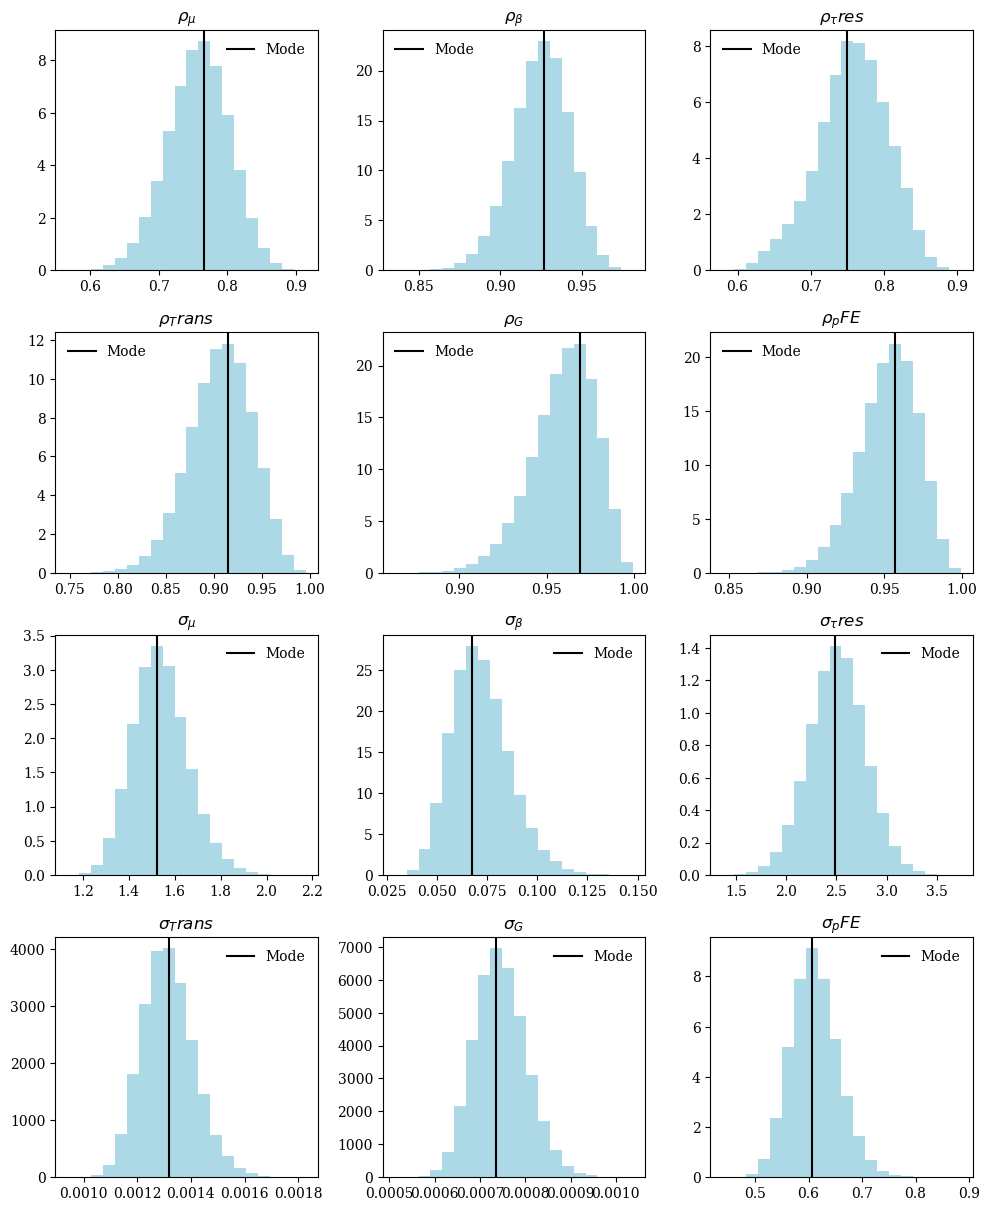

In [32]:
# Plot the sample distribution of accepted draws (posterior)
modes = est.plot_posterior_sample(accepted, colors=['', 'lightblue', '', '', '', '', 'black'], legends=leg, nb_bins=20)

In [33]:
print('------- Table 3: Bayesian estimation (benchmark) -------')
# Statistics of the posterior distribution
means = accepted.mean(axis=0)
stds = accepted.std(axis=0)
percentile5 = np.percentile(accepted, 5, axis=0)
percentile95 = np.percentile(accepted, 95, axis=0)
results = pd.DataFrame(dict({'Mode': modes, 'Mean': means, 'Std': stds, '5th perc.': percentile5, '95th perc.': percentile95}), index=leg)
results

------- Table 3: Bayesian estimation (benchmark) -------


,Mode,Mean,Std,5th perc.,95th perc.
$\rho_μ$,0.766484,0.757914,0.045062,0.681460,0.829814
$\rho_β$,0.926745,0.924775,0.017281,0.894934,0.951735
$\rho_τres$,0.749970,0.756870,0.048441,0.670082,0.832819
$\rho_Trans$,0.915161,0.907210,0.032652,0.850868,0.958017
$\rho_G$,0.968888,0.959718,0.018113,0.926840,0.985830
$\rho_pFE$,0.956902,0.952383,0.018764,0.918976,0.980328
$\sigma_μ$,1.521211,1.539128,0.120480,1.353193,1.748245
$\sigma_β$,0.067365,0.071748,0.014453,0.050226,0.097360
$\sigma_τres$,2.490932,2.508043,0.281048,2.042927,2.971302
$\sigma_Trans$,0.001317,0.001315,0.000098,0.001165,0.001485


<a id="5-Shock"></a>
## 5 Shock decomposition

In [34]:
ρ_mu, ρ_beta, ρ_Tax, ρ_Trans, ρ_G, ρ_pFE, σ_mu, σ_beta, σ_Tax, σ_Trans, σ_G, σ_pFE = np.array(results['Mean'])

In [35]:
data_decomp = pd.read_excel('data_PLF2023.xlsx', index_col=0)

In [36]:
data_decomp['Y']   = data_decomp['Y'] * ss['Y'] / 100
data_decomp['pFE'] = (data_decomp['pFE'] - hist_mean['pFE']) * ss['pFE'] / 100
data_decomp['G']   = data_decomp['G'] * ss['G'] / 100
data_decomp['TransEXO'] = data_decomp['TransEXO'] * ss['Trans'] / 100
data_decomp['pi']   = data_decomp['pi'] / 100

In [37]:
outputs_info = {'Y': {'label': 'Output', 'color': 'orangered'},
         'pi': {'label': 'Inflation', 'color': 'crimson'},
         'C': {'label': 'Consumption', 'color': 'tab:red'},
         'w': {'label': 'Real wage', 'color': 'black'},
         'r': {'label': 'Real interest rate', 'color': 'darkgrey'},
         'i': {'label': 'Nominal interest rate', 'color': 'slategrey'},
         'L': {'label': 'Hours worked', 'color': 'grey'},
         'Br': {'label': 'Debt-to-GDP ratio', 'color': 'darkblue'},
         'bouclier': {'label': 'Tariff shield', 'color': 'pink'},
         'bouclier_Y': {'label': 'Tariff shield (% GDP)', 'color': 'pink'},
         'bouclier_Yss': {'label': 'Tariff shield (% long-term GDP)', 'color': 'pink'},
         'pFE': {'label': 'Energy price', 'color': 'royalblue'},
         'G': {'label': 'Public spending', 'color': 'yellowgreen'},
         'subv': {'label': 'Energy subsidy', 'color': 'skyblue'},
         'TransEXO': {'label': 'Transfers', 'color': 'darkgreen'},
         'incomp': {'label': 'Incompressible consumption', 'color': 'palevioletred'},
         'E': {'label': 'Household energy', 'color': 'red'},
         'YFE': {'label': 'Firm energy', 'color': 'darkred'},
         'piFE': {'label': 'Energy inflation', 'color': 'red'}}
inputs_info = {'beta': {'label': 'Preference', 'color': 'lightpink', 'rho': ρ_beta},
         'Z': {'label': 'TFP', 'color': 'crimson', 'rho': 0.7},
         'mu': {'label': 'Price markup', 'color': 'orange', 'rho': ρ_mu},
         'muw': {'label': 'Wage markup', 'color': 'orangered', 'rho': 0.6},
         'pFE': {'label': 'Energy price', 'color': 'royalblue', 'rho': ρ_pFE},
         'G': {'label': 'Public spending', 'color': 'yellowgreen', 'rho': ρ_G},
         'subv': {'label': 'Energy subsidy', 'color': 'skyblue', 'rho': 0.8},
         'Subv': {'label': 'Incompressible consumption', 'color': 'gold', 'rho': 0.8},
         'Subv1': {'label': 'Pure transfers', 'color': 'chocolate', 'rho': 0.8},
         'Subv2': {'label': 'Transfers for bottom 30%', 'color': 'chocolate', 'rho': 0.8},
         'bouclier_Yss': {'label': 'Transfers to households', 'color': 'skyblue', 'rho': 0.8},
         'TransEXO': {'label': 'Transfers', 'color': 'darkgreen', 'rho': ρ_Trans},
         'TaxEXO': {'label': 'Measurement error', 'color': 'navajowhite', 'rho': ρ_Tax},
         'rstar': {'label': 'Monetary policy', 'color': 'lightgrey', 'rho': 0.4},
         'kappaw': {'label': 'Wage rigidity', 'color': 'lightgrey', 'rho': 0.95},
         'χl': {'label': 'Income tax distortion', 'color': 'yellow', 'rho': 0},
         'χc': {'label': 'Consumption tax distortion', 'color': 'yellow', 'rho': 0}}

In [38]:
pFE = data_decomp[['pFE']]
Oilsubs1 = pFE.copy()
# Calibration of the subsidy (see appendix)
Oilsubs1.iloc[10:17] = 0.8 * pFE.iloc[10:17] # Subsidy 2Q2022 - 4Q2023

# Alternative specification
Oilsubs2 = pFE.copy()
Oilsubs2.iloc[10:21] = 0.8 * pFE.iloc[10:21] # Subsidy 2Q2022 - 4Q2024

------ Figure 12a: Output ------


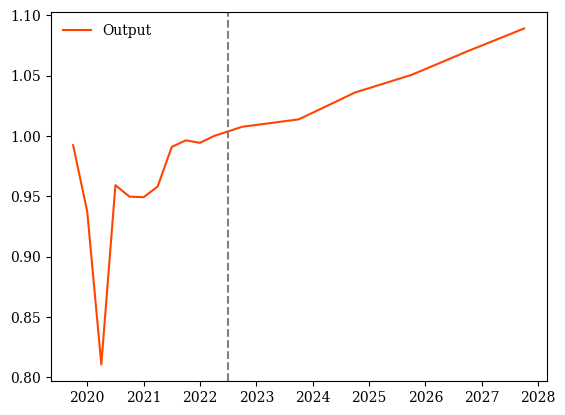

------ Figure 12b: Inflation ------


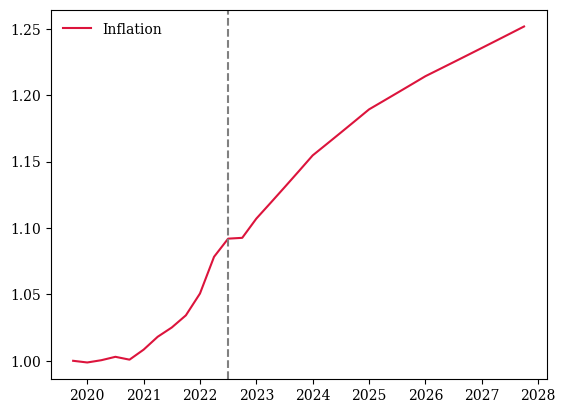

------ Figure 12c: Energy price ------


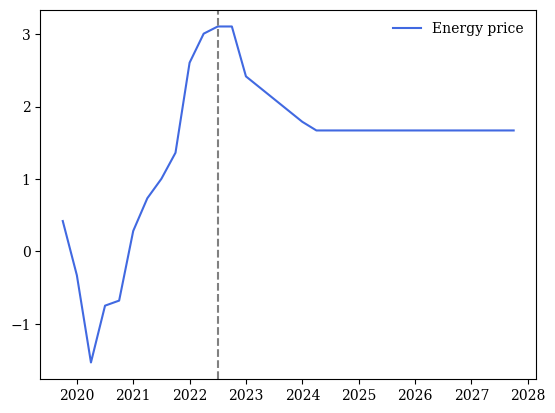

------ Figure 12d: Public spending ------


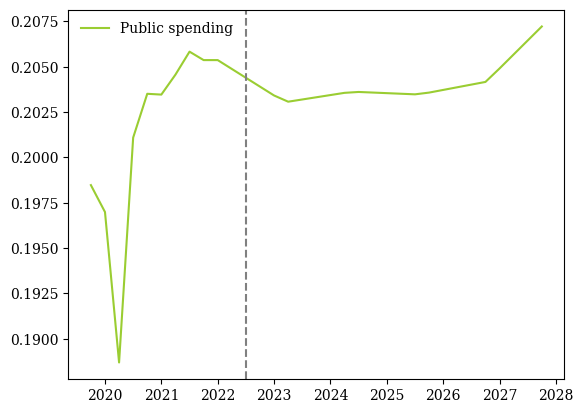

------ Figure 12e: Transfers ------


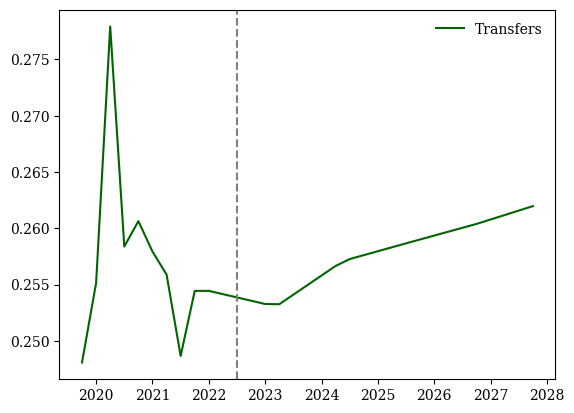

------ Figure 12f: Debt-to-GDP ratio ------


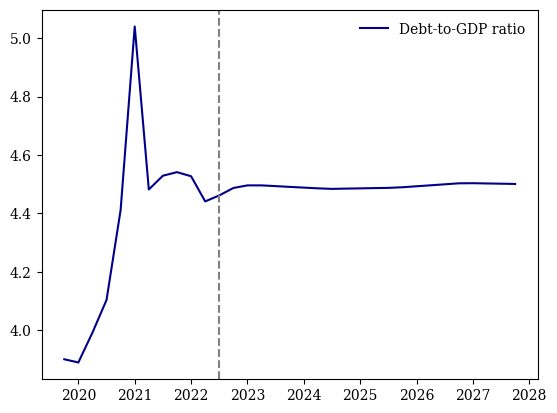

In [39]:
# Figure 12: Data
for (i, elem) in enumerate(data_decomp.columns):
    print('------ Figure 12'+string.ascii_lowercase[i]+': '+outputs_info[elem]['label']+' ------')
    plt.plot(data_decomp.index, data_decomp[elem], color=outputs_info[elem]['color'], label=outputs_info[elem]['label'])
    plt.axvline(2022.5, linestyle='--', color='grey')
    plt.legend(frameon=False)
    if save_fig:
        plt.savefig('Figures/Figure12'+string.ascii_lowercase[i]+'.eps'.format(elem), dpi=600)
    plt.show()

In [40]:
# Select the shocks and observed variables at play
inputs = ['pFE', 'G', 'TransEXO', 'TaxEXO', 'mu', 'beta', 'subv'] # Shocks
outputs = ['Y', 'pi', 'pFE', 'G', 'TransEXO', 'Br', 'subv'] # Variables

#### Stationarise the data

In [41]:
datas_df = data_decomp[outputs[:-1]]

# Inflation rate
datas_df['pi'] = datas_df['pi'].pct_change().fillna(0)

# Detrend
for elem in ['Y', 'G', 'TransEXO']: 
    datas_df[elem] = remove_trend(datas_df[elem], trend[elem])

# Remove the historical means
datas_df['Br'] = datas_df['Br'] - 4.0

# Tariff shield
pFE_HA = np.array(Oilsubs1).reshape(len(datas_df))
datas_df['subv'] = np.array(datas_df['pFE']) - pFE_HA

------ Figure 13a: Output ------


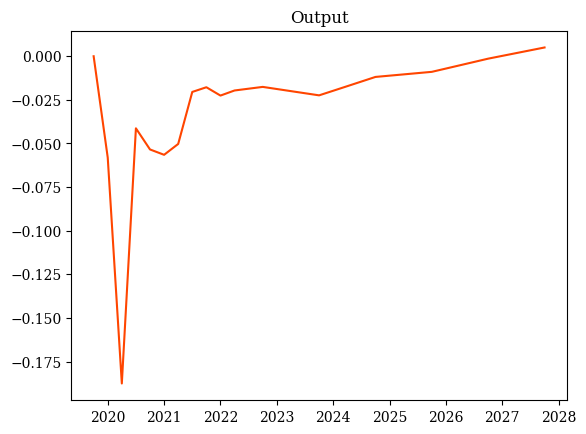

------ Figure 13b: Inflation ------


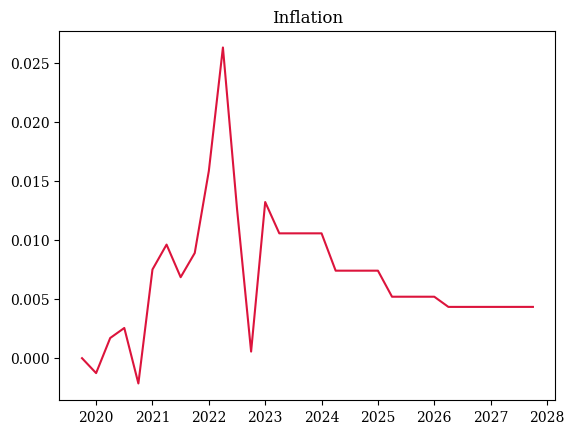

------ Figure 13c: Energy price ------


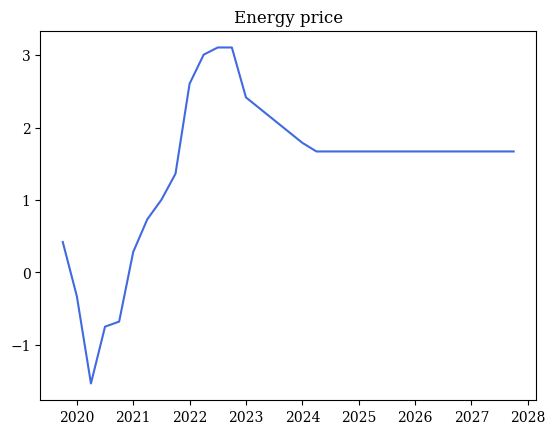

------ Figure 13d: Public spending ------


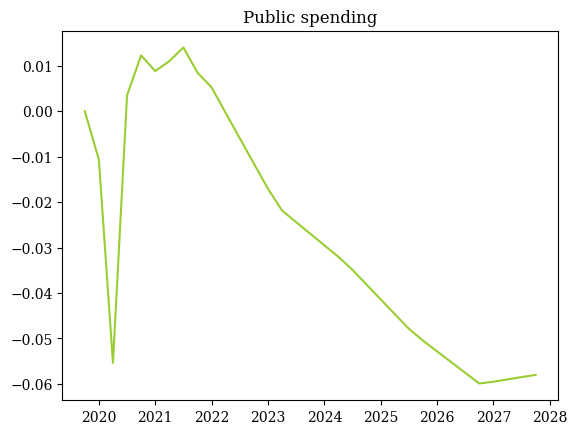

------ Figure 13e: Transfers ------


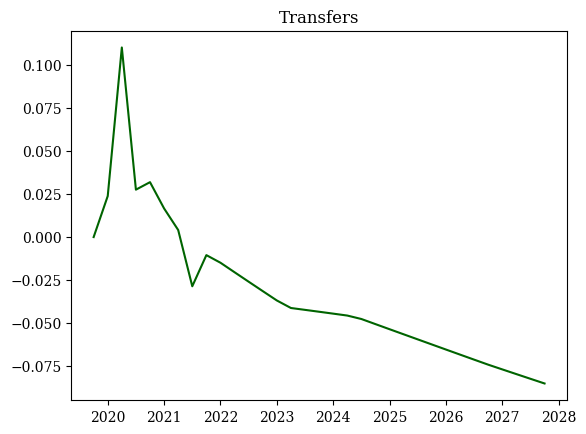

------ Figure 13f: Debt-to-GDP ratio ------


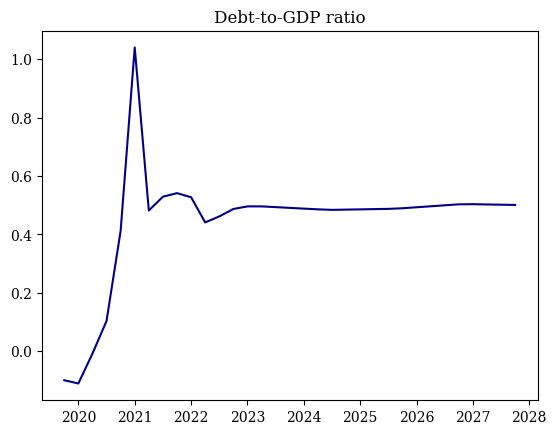

In [42]:
# Figure 13
# Plot the stationarised data
dates = data_decomp.index
for (i,elem) in enumerate(datas_df.columns):
    if elem not in ['pFE_HA', 'subv']:
        print('------ Figure 13'+string.ascii_lowercase[i]+': '+outputs_info[elem]['label']+' ------')
        plt.plot(dates, datas_df[elem], color=outputs_info[elem]['color'])
        plt.title(outputs_info[elem]['label'])
        if save_fig:
            plt.savefig('Figures/Figure13'+string.ascii_lowercase[i]+'.eps'.format(elem), dpi=600)
        plt.show()

In [43]:
# Save the size of the tariff shield
util.save_result(datas_df['subv'], 'Results/BenchmarkTariffShield')

### Reestimation of the persistence

In [44]:
data_stat_lucas = datas_df.copy()

new_estim_G = AR_estim(np.array(data_stat_lucas['G']), verbose=False)
new_estim_Trans = AR_estim(np.array(data_stat_lucas['TransEXO']), verbose=False)

In [45]:
ρ_G2 = new_estim_G['ρ']
σ_G2 = new_estim_G['σ']
ρ_Trans2 = new_estim_Trans['ρ']
σ_Trans2 = new_estim_Trans['σ']

In [46]:
# Table 4: Reestimated parameters
print('----- Table 4: Parameter re-estimation -----')
print('Before G (rho):', np.round(ρ_G, 6))
print('Before G (sigma)', np.round(σ_G, 6))
print('After G (rho):', np.round(ρ_G2, 6))
print('After G (sigma)', np.round(σ_G2, 6))

print('Before T (rho):', np.round(ρ_Trans, 6))
print('Before T (sigma)', np.round(σ_Trans, 6))
print('After T (rho):', np.round(ρ_Trans2, 6))
print('After T (sigma)', np.round(σ_Trans2, 6))

----- Table 4: Parameter re-estimation -----
Before G (rho): 0.959718
Before G (sigma) 0.000746
After G (rho): 0.864387
After G (sigma) 0.013091
Before T (rho): 0.90721
Before T (sigma) 0.001315
After T (rho): 0.857879
After T (sigma) 0.022124


In [47]:
update_Lucas = True

if update_Lucas:
    inputs_info['G']['rho'] = ρ_G2
    inputs_info['TransEXO']['rho'] = ρ_Trans2

### Shock decomposition

In [48]:
def build_impulses(G, inputs, outputs, T, inputs_info):
    # Parameters of the shocks
    rhos = {}
    sigmas = {}
    for i in range(len(inputs)):
        rhos[inputs[i]] = inputs_info[inputs[i]]['rho']
        sigmas[inputs[i]] = 1
    
    # Initialise
    impulses = {}
    G_new = {}
    for out in outputs:
        s = {}
        for inp in inputs:
            s[inp] = 0
        G_new[out] = s
        
    for inp in inputs:
        own_shock = sigmas[inp] * rhos[inp]**np.arange(T)
        interm = {}
        for out in outputs:
            # Shocks that are inputs and outputs
            if out in inputs:
                if inp == out:
                    interm[out] = np.eye(T) @ own_shock
                    G_new[out][inp] = np.eye(T)
                else:
                    interm[out] = np.zeros(T)
                    G_new[out][inp] = np.zeros((T, T))
            # Other variables
            else:
                if inp in G[out].keys():
                    if type(G[out][inp]) == ssj.classes.sparse_jacobians.SimpleSparse:
                        interm[out] = G[out][inp].matrix(T) @ own_shock
                        G_new[out][inp] = G[out][inp].matrix(T)
                    else:
                        interm[out] = G[out][inp][:T, :T] @ own_shock
                        G_new[out][inp] = G[out][inp][:T, :T]
                else:
                    interm[out] = np.zeros(T)
                    G_new[out][inp] = np.zeros((T, T))
        interm[inp] = own_shock
        impulses[inp] = interm
    return impulses, G_new, rhos, sigmas

In [49]:
Tobs = len(datas_df)
impulses, _, rhos, sigmas = build_impulses(G_estim, inputs, outputs, Tobs, inputs_info)

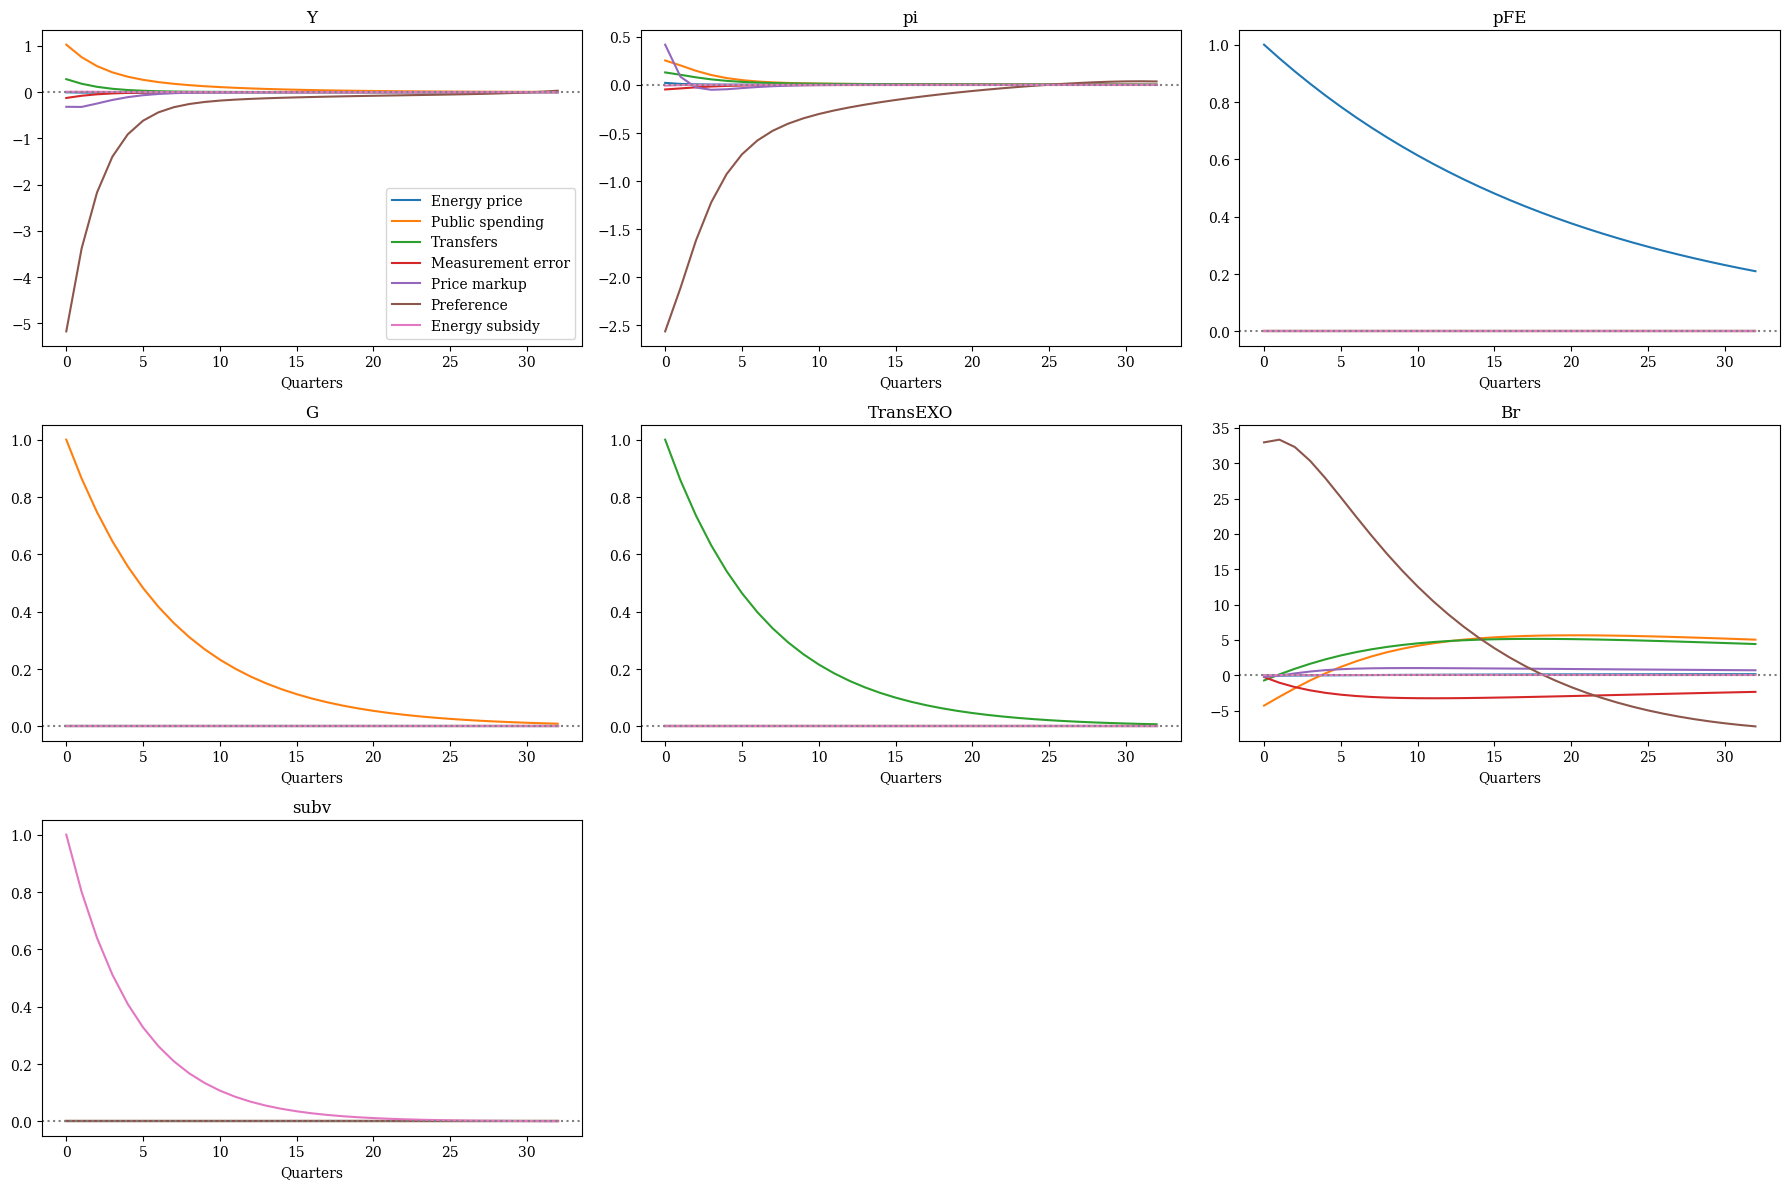

In [50]:
# Check the behaviour of the IRFs prior to the shock decomposition
nb = (len(outputs) // 3) + 1
labels = {}
for elem in inputs_info.keys():
    labels[elem] = inputs_info[elem]['label']
plot_impulses(impulses, labels, outputs, (nb, 3), T=datas_df.shape[0], figsize=(nb*6,12))

In [51]:
# Stack the IRFs
M = np.empty((Tobs, len(outputs), len(inputs)))
for no, o in enumerate(outputs):
    for ns, s in enumerate(inputs):
        M[:, no, ns] = impulses[s][o]

In [52]:
eps_hat_est, Ds = back_out_shocks(M, np.array(datas_df), preperiods=0)
# Most probable shocks
eps_hat_est_df = pd.DataFrame(eps_hat_est, columns=[inputs], index=dates) 

In [53]:
# Reconstruct the shocks thanks to the innovations
for elem in inputs:
    globals()['shock_%s' % elem] = list(eps_hat_est_df[elem].iloc[0])
    for t in range(len(datas_df)-1):
        globals()['shock_%s' % elem].append(inputs_info[elem]['rho'] * globals()['shock_%s' % elem][t] + float(eps_hat_est_df[elem].iloc[t]))

/var/folders/y5/yc40lhf929g9j15tklhlflz00000gn/T/ipykernel_54158/1867244582.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead


### Reconstruct the observations given the shocks

In [54]:
new_outputs = ['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'bouclier_Y', 'bouclier_Yss', 'incomp', 'E', 'YFE', 'piFE']
_, G, _, _ = build_impulses(G_estim, inputs, new_outputs, Tobs, inputs_info)

In [55]:
new_M = fcst.generate_M(inputs, new_outputs, sigmas, rhos, Tobs, G)
new_Ds = fcst.reconstruct(new_M, eps_hat_est)

In [56]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s' % elem] = new_Ds[:, i, :].sum(axis=1)

In [57]:
# Variance contributions
ts = [i for i in range(9,33)]
output_contribs = Ds[:, 0, :]
infl_contribs = Ds[:, 1, :]
debt_contribs = Ds[:, 5, :]

outp = {}
infl = {}
debt = {}

for t in ts:
    outp[datas_df.index[t]] = 100 * (output_contribs[t, :]**2) / np.sum((output_contribs[t, :]**2))
    infl[datas_df.index[t]] = 100 * (infl_contribs[t, :]**2) / np.sum((infl_contribs[t, :]**2))
    debt[datas_df.index[t]] = 100 * (debt_contribs[t, :]**2) / np.sum((debt_contribs[t, :]**2))

In [58]:
# Table 22: Variance decomposition
print('------- Table 22: Variance decomposition (output row) -------')
dates_to_include = [2022.0, 2022.25, 2022.50, 2022.75, 2023.0, 2023.25, 2023.50, 2023.75, 2024.25, 2025.25, 2026.25, 2027.25]

df_output = pd.DataFrame(outp, index=inputs)
df_output[dates_to_include].round(2).reindex(['beta', 'mu', 'TaxEXO', 'G', 'TransEXO', 'pFE', 'subv'])

------- Table 22: Variance decomposition (output row) -------


,2022.00,2022.25,2022.50,2022.75,2023.00,2023.25,2023.50,2023.75,2024.25,2025.25,2026.25,2027.25
beta,1.92,18.09,8.42,7.24,15.89,23.20,22.03,20.76,24.35,13.86,9.01,7.59
mu,1.38,0.25,2.29,14.71,3.25,1.59,0.86,0.34,3.72,20.83,29.84,38.65
TaxEXO,0.48,0.13,1.39,0.00,2.33,1.15,1.27,1.58,2.75,2.76,4.07,4.13
G,1.08,0.91,4.29,7.85,14.76,22.93,29.03,35.36,42.12,46.59,45.18,38.96
TransEXO,3.09,1.76,1.83,1.82,2.41,2.94,2.93,2.93,2.61,2.62,2.53,2.74
pFE,92.05,75.92,78.55,65.77,59.62,46.76,42.54,37.84,24.44,13.34,9.37,7.93
subv,0.00,2.93,3.23,2.59,1.73,1.44,1.34,1.18,0.02,0.00,0.00,0.00


In [59]:
# Table 22: Variance decomposition
print('------- Table 22: Variance decomposition (inflation row) -------')
df_infl = pd.DataFrame(infl, index=inputs)
df_infl[dates_to_include].round(2).reindex(['beta', 'mu', 'TaxEXO', 'G', 'TransEXO', 'pFE', 'subv'])

------- Table 22: Variance decomposition (inflation row) -------


,2022.00,2022.25,2022.50,2022.75,2023.00,2023.25,2023.50,2023.75,2024.25,2025.25,2026.25,2027.25
beta,0.02,2.81,3.85,5.67,43.03,64.97,62.85,61.81,60.51,43.20,38.65,37.48
mu,19.46,0.08,13.34,39.77,34.86,2.40,0.84,0.78,8.85,18.08,18.00,18.20
TaxEXO,0.01,0.02,0.44,0.02,3.56,2.27,2.16,2.39,3.33,3.43,6.18,7.36
G,0.01,0.11,0.82,1.86,9.96,12.98,13.00,13.53,11.45,12.00,14.17,12.59
TransEXO,0.27,0.61,1.29,1.81,7.63,8.75,8.12,7.88,5.86,5.85,7.53,9.48
pFE,80.23,94.33,79.56,50.69,0.88,8.63,13.02,13.60,9.70,17.44,15.46,14.89
subv,0.00,2.05,0.70,0.18,0.07,0.01,0.00,0.00,0.28,0.00,0.00,0.00


In [60]:
# Table 22: Variance decomposition
print('------- Table 22: Variance decomposition (debt ratio row) -------')
df_debt = pd.DataFrame(debt, index=inputs)
df_debt[dates_to_include].round(2).reindex(['beta', 'mu', 'TaxEXO', 'G', 'TransEXO', 'pFE', 'subv'])

------- Table 22: Variance decomposition (debt ratio row) -------


,2022.00,2022.25,2022.50,2022.75,2023.00,2023.25,2023.50,2023.75,2024.25,2025.25,2026.25,2027.25
beta,13.22,1.22,0.01,1.39,9.82,19.26,23.48,25.36,25.94,18.05,9.74,5.00
mu,41.58,47.92,51.85,52.91,47.98,36.14,28.54,22.38,13.12,4.09,0.61,0.00
TaxEXO,11.59,14.15,17.65,24.50,32.19,39.48,44.54,48.09,53.27,64.82,72.07,74.69
G,0.71,0.02,0.29,1.17,2.37,2.55,1.80,1.08,0.15,0.32,1.85,3.90
TransEXO,14.63,14.45,12.35,9.16,6.12,2.42,0.43,0.02,1.77,7.12,11.20,13.03
pFE,18.27,22.24,17.82,10.79,1.39,0.01,1.06,2.91,5.65,5.56,4.52,3.36
subv,0.00,0.00,0.03,0.07,0.13,0.14,0.15,0.16,0.10,0.05,0.02,0.01


<a id="6-Lucas"></a> 

## 6 Uncertainty

In [61]:
np.random.seed(10)
if update_Lucas:
    eps_draws = fcst.generate_draws(eps_hat_est_df, 1000, 11, 
                                    labels=['Energy price', 'Government spending', 'Transfers', 'Taxes', 'Price markup', 'Preference'],
                                    sigmas=[σ_pFE, σ_G2, σ_Trans2, σ_Tax, σ_mu, σ_beta], mus=[0]*n_estim, display=False)
    oldeps_draws = fcst.generate_draws(eps_hat_est_df, 1000, 11, 
                                    labels=['Energy price', 'Government spending', 'Transfers', 'Taxes', 'Price markup', 'Preference'],
                                    sigmas=[σ_pFE, σ_G, σ_Trans, σ_Tax, σ_mu, σ_beta], mus=[0]*n_estim, display=False)
else:
    eps_draws = fcst.generate_draws(eps_hat_est_df, 1000, 11, 
                                    labels=['Energy price', 'Government spending', 'Transfers', 'Taxes', 'Price markup', 'Preference'],
                                    sigmas=[σ_pFE, σ_G, σ_Trans, σ_Tax, σ_mu, σ_beta], mus=[0]*n_estim, display=False)

In [62]:
def plot_uncertainty(eps_hat_est_df, results, inputs_info, tmin=11, tmax=32, var=['mu', 'beta', 'pFE', 'G', 'TransEXO', 'TaxEXO'], fignb=15, savefig=save_fig):
    T   = results[(var[0], )].shape[0]
    for (k, elem) in enumerate(var):
        print('------ Figure '+str(fignb)+string.ascii_lowercase[k]+': '+inputs_info[elem]['label']+' ------')
        plt.figure() 
        for i in range(1,T):
            plt.plot(eps_hat_est_df.iloc[tmin:tmax+1].index, results[(elem,)][i, tmin:tmax+1], color='lightgrey')
        plt.plot(eps_hat_est_df.iloc[tmin:tmax+1].index, np.array(eps_hat_est_df[elem].iloc[tmin:tmax+1]), color='black', label='Benchmark')
        plt.plot(eps_hat_est_df.iloc[tmin:tmax+1].index, np.mean(results[(elem,)][:,tmin:tmax+1], axis=0), color='red', label='Average')
        legend_title = inputs_info.get(elem, {}).get('label', '')    
        plt.legend(frameon=False, title=legend_title)
        if savefig:
            plt.savefig('Figures/Figure'+str(fignb)+string.ascii_lowercase[k]+'.eps', dpi=600)
        plt.show()

------ Figure 15a: Price markup ------


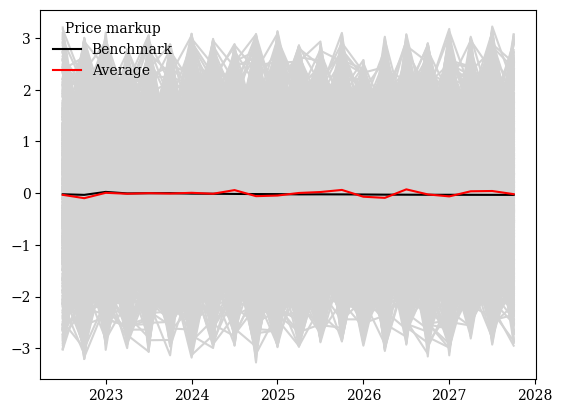

------ Figure 15b: Preference ------


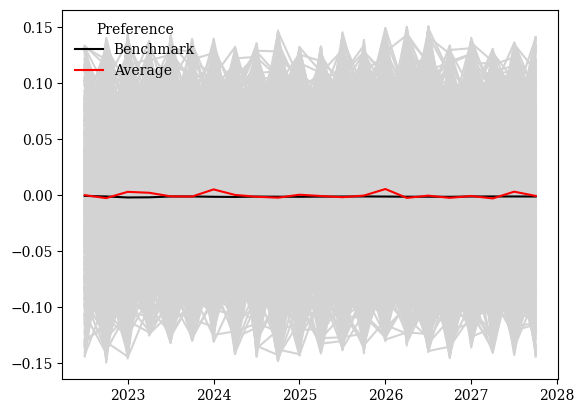

------ Figure 15c: Energy price ------


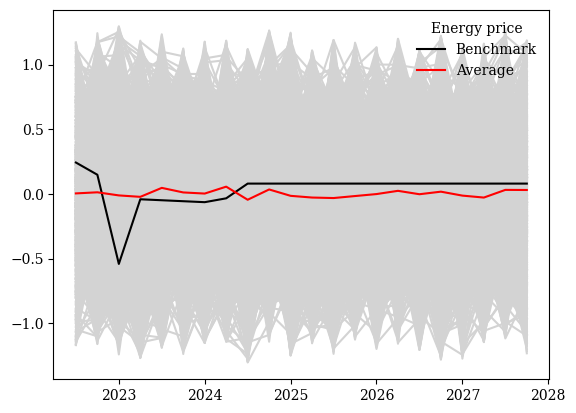

------ Figure 15d: Public spending ------


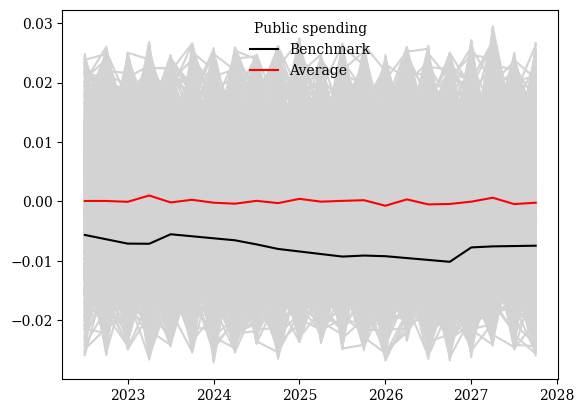

------ Figure 15e: Transfers ------


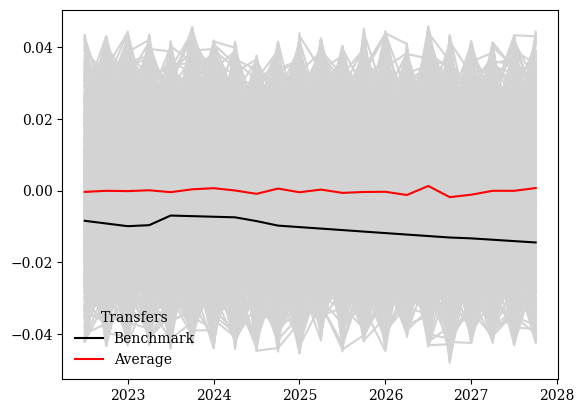

------ Figure 15f: Measurement error ------


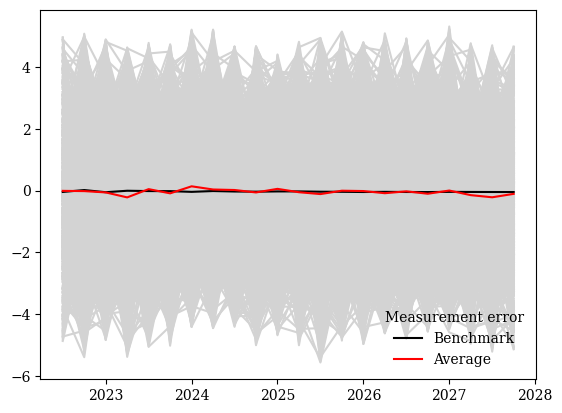

------ Figure 14a: Public spending ------


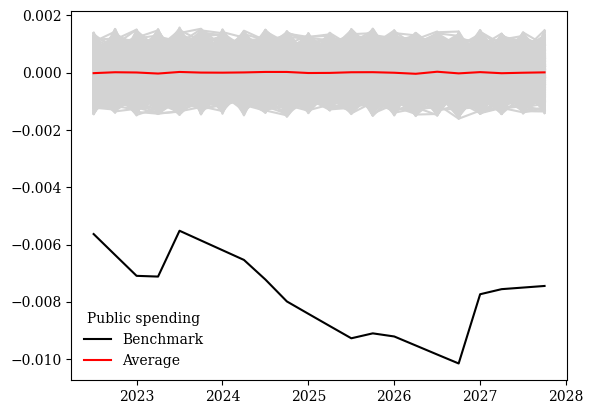

------ Figure 14b: Transfers ------


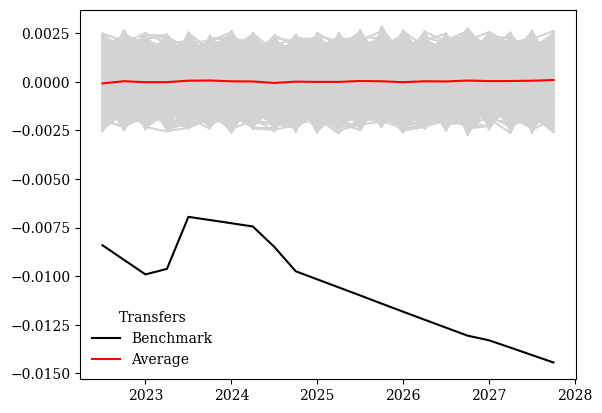

In [63]:
# Figures 14 and 15
if uncertainty_flag:
    plot_uncertainty(eps_hat_est_df, eps_draws, inputs_info)
    plot_uncertainty(eps_hat_est_df, oldeps_draws, inputs_info, var=['G', 'TransEXO'], fignb=14)

<a id="7-Scenario"></a> 

## 7 Scenario

### 7.1 Benchmark : Tariff shield

In [64]:
impulses, _, rhos, sigmas = build_impulses(G_estim, inputs, outputs, Tobs, inputs_info)

In [65]:
# Stack the IRFs
M = np.empty((Tobs, len(outputs), len(inputs)))
for no, o in enumerate(outputs):
    for ns, s in enumerate(inputs):
        M[:, no, ns] = impulses[s][o]

In [66]:
eps_hat_est, Ds = back_out_shocks(M, np.array(datas_df), preperiods=0)
# Most probable shocks
eps_hat_est_df = pd.DataFrame(eps_hat_est, columns=[inputs], index=dates) #data_df_stat.index)

------ Figure 18: Shock decomposition (long) ------


/Users/selmamalmberg/Downloads/TariffShield/TOOLS/forecasts.py:64: UserWarning: The figure layout has changed to tight


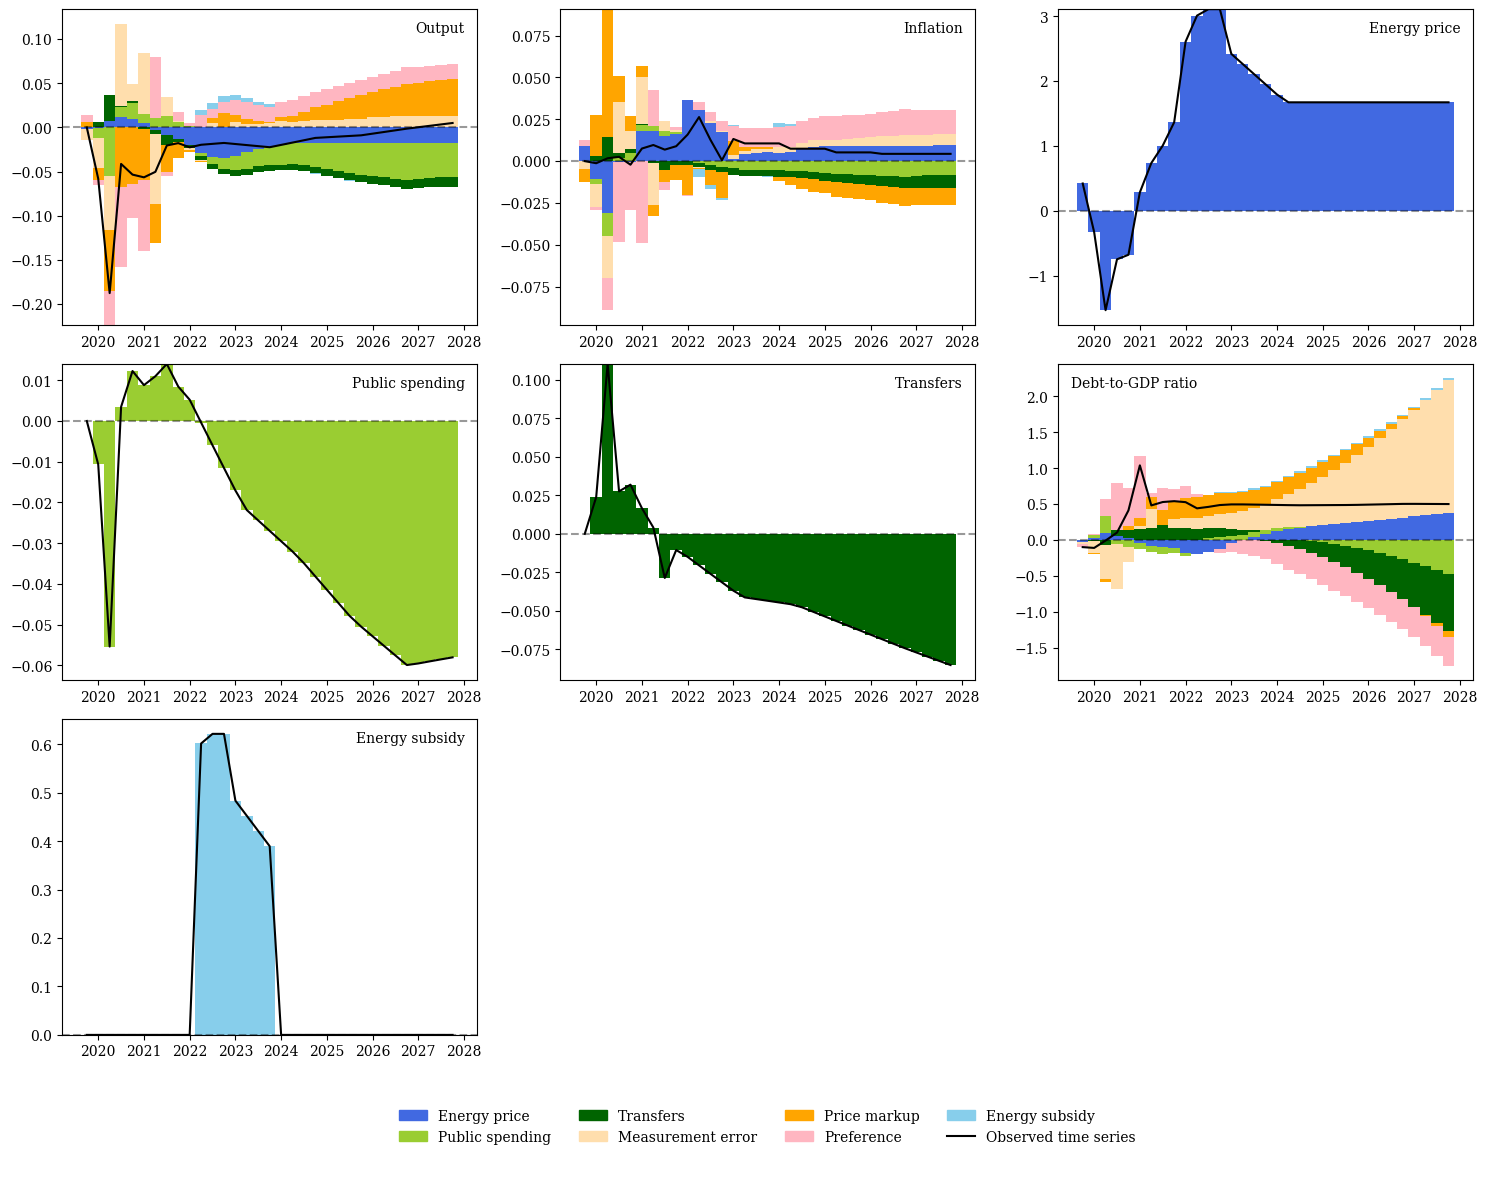

In [67]:
# Figure 18: Shock decomposition (long version)
print('------ Figure 18: Shock decomposition (long) ------')
dates = [2019.75 + 0.25*i for i in range(len(datas_df))]
fcst.plot_shock_decomposition_1axis(Ds, np.array(datas_df), inputs, inputs_info, 
                        outputs, outputs_info, dates, savefig=save_fig,
                        name='Figures/Figure18.eps')

------ Figure 3: Shock decomposition ------


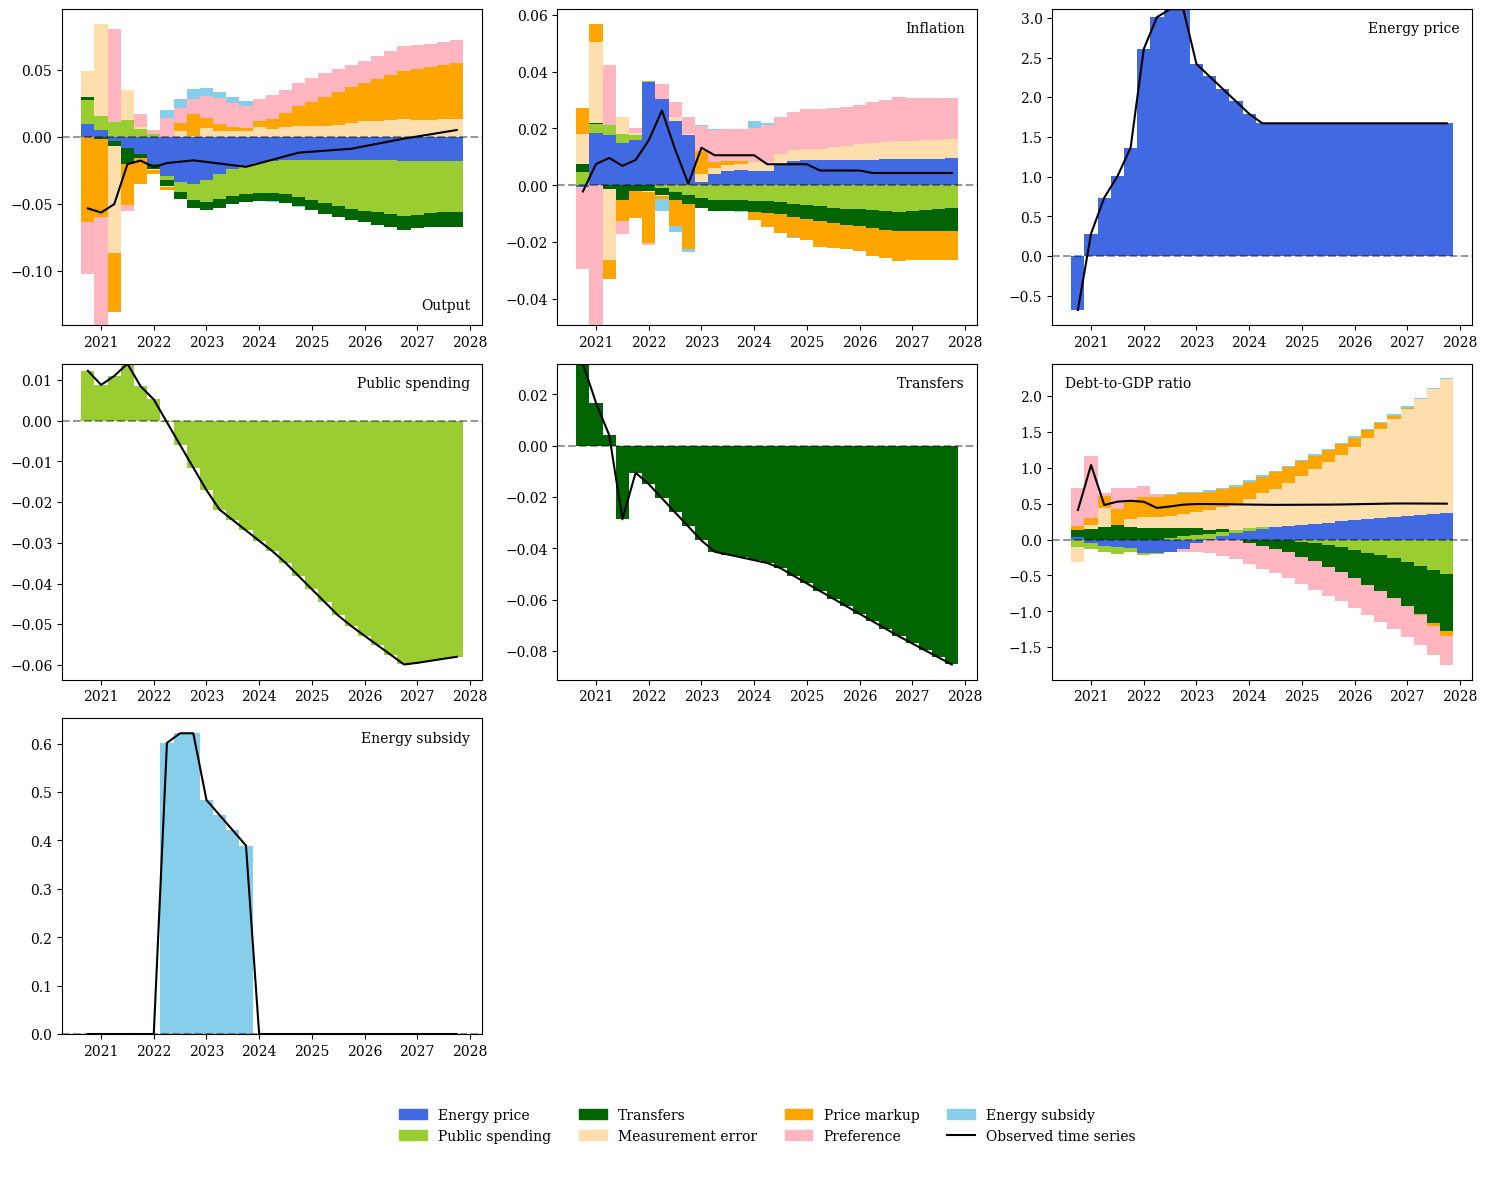

In [68]:
# Figure 3: Shock decomposition
print('------ Figure 3: Shock decomposition ------')
fcst.plot_shock_decomposition_1axis(Ds[4:, :, :], np.array(datas_df)[4:], inputs, inputs_info,
                               outputs, outputs_info, dates[4:], savefig=save_fig,
                               name='Figures/Figure3.eps')

In [69]:
new_outputs = ['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'bouclier_Y', 'bouclier_Yss', 'incomp', 'E', 'YFE']
_, G, _, _ = build_impulses(G_estim, inputs, new_outputs, Tobs, inputs_info)
new_M = fcst.generate_M(inputs, new_outputs, sigmas, rhos, Tobs, G)
new_Ds = fcst.reconstruct(new_M, eps_hat_est)

In [70]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s' % elem] = new_Ds[:, i, :].sum(axis=1)

In [71]:
Y_level   = fcst.rebuild_level(built_Y, 'Output', len(built_Y), g=trend['Y'])
C_level   = fcst.rebuild_level(built_C, 'Consumption', len(built_C), g=trend['Y'])
w_level   = fcst.rebuild_level(built_w, 'Real wages', len(built_w))
L_level   = fcst.rebuild_level(built_L, 'Labor', len(built_L))
r_level   = fcst.rebuild_level(built_r, 'Real rate', None)
i_level   = fcst.rebuild_level(built_i, 'Nominal rate', None)
IPC_level = fcst.rebuild_level(built_pi, 'Prices', len(built_pi))
Br_level  = fcst.rebuild_level(built_Br, 'Debt-to-GDP ratio', None)
E_level   = fcst.rebuild_level(built_E, 'Energy firm', len(built_E), g=trend['Y'])
YFE_level = fcst.rebuild_level(built_YFE, 'Energy household', len(built_YFE), g=trend['Y'])

level_df = pd.DataFrame(np.array([Y_level, IPC_level, C_level, w_level, L_level, r_level, i_level, Br_level, E_level, YFE_level]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

In [72]:
level_df['year'] = np.floor(level_df.index)
print('---- Content for the tables (Tables 1, 5, 6, 7, 8, 9, 10): Tariff shield row (2022 and 2023) ----')
debt_2027 = level_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')

---- Content for the tables (Tables 1, 5, 6, 7, 8, 9, 10): Tariff shield row (2022 and 2023) ----
Debt-to-GDP ratio (in 2027):  112.6 %
2022 GDP growth:  2.85 %
2023 GDP growth:  1.0 %
2022 inflation:  6.5 %
2023 inflation:  3.5 %


### 7.2 No tariff shield

In [73]:
# Set subsidy shock to 0
eps_hat_est_nosubv = eps_hat_est_df.copy()
eps_hat_est_nosubv[['subv']] = 0
Ds_nosubv = fcst.reconstruct(new_M, np.array(eps_hat_est_nosubv))

In [74]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s_nosubv' % elem] = Ds_nosubv[:, i, :].sum(axis=1)

In [75]:
Y_level_nosubv   = fcst.rebuild_level(built_Y_nosubv, 'Output', len(built_Y_nosubv), g=trend['Y'])
C_level_nosubv   = fcst.rebuild_level(built_C_nosubv, 'Consumption', len(built_C_nosubv), g=trend['Y'])
w_level_nosubv   = fcst.rebuild_level(built_w_nosubv, 'Real wages', len(built_w_nosubv))
L_level_nosubv   = fcst.rebuild_level(built_L_nosubv, 'Labor', len(built_L_nosubv))
r_level_nosubv   = fcst.rebuild_level(built_r_nosubv, 'Real rate', None)
i_level_nosubv   = fcst.rebuild_level(built_i_nosubv, 'Nominal rate', None)
IPC_level_nosubv = fcst.rebuild_level(built_pi_nosubv, 'Prices', len(built_pi_nosubv))
Br_level_nosubv  = fcst.rebuild_level(built_Br_nosubv, 'Debt-to-GDP ratio', None)
E_level_nosubv   = fcst.rebuild_level(built_E_nosubv, 'Energy firm', len(built_E_nosubv), g=trend['Y'])
YFE_level_nosubv = fcst.rebuild_level(built_YFE_nosubv, 'Energy household', len(built_YFE_nosubv), g=trend['Y'])

level_nosubv_df  = pd.DataFrame(np.array([Y_level_nosubv, IPC_level_nosubv, C_level_nosubv, w_level_nosubv, L_level_nosubv, r_level_nosubv, i_level_nosubv, Br_level_nosubv, E_level_nosubv, YFE_level_nosubv]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

#### Inequalities

In [76]:
varineq = ['C_', 'CTOT_', 'INC_', 'A_']
varineq_names = ['Consumption', 'Consumption (incl. incompressible energy cons.)', 'Net income', 'Wealth']

In [77]:
nS = len(ss.internals['household']['e_grid'])
stats_prod = pd.DataFrame(np.array([[ss['A_' + str(i)]/ss.internals['household']['pi_e'][i] for i in range(nS)],
                              [ss['C_' + str(i)]/ss.internals['household']['pi_e'][i] for i in range(nS)],
                              [ss['INC_' + str(i)]/ss.internals['household']['pi_e'][i] for i in range(nS)]]).transpose(),
                             columns=['Wealth', 'Consumption', 'Net income'],
                             index=['P' + str(i+1) for i in range(nS)])

In [78]:
colors = ['blue', '#7692FF', '#C2CEFF', 'black', '#FF9999', '#FF4747', 'red']

In [79]:
ineq_var = ['C', 'INC', 'A']
ineq_outputs = [elem+'_'+str(i) for elem in ineq_var for i in range(7)]
_, G_ineq, _, _ = build_impulses(G_estim, inputs, ineq_outputs, Tobs, inputs_info)

ineq_M  = fcst.generate_M(inputs, ineq_outputs, sigmas, rhos, Tobs, G_ineq)
ineq_Ds = fcst.reconstruct(ineq_M, eps_hat_est)
ineq_Ds_nosubv = fcst.reconstruct(ineq_M, np.array(eps_hat_est_nosubv))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s' % (elem, i)] = ineq_Ds[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s' % (elem, i)], 'Consumption',
                                                                  len(globals()['built_%s_%s' % (elem, i)]))
        globals()['built_%s_%s_nosubv' % (elem, i)] = ineq_Ds_nosubv[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_nosubv' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_nosubv' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_nosubv' % (elem, i)]))

In [80]:
ineq_df = pd.DataFrame(np.array([C_0_level, C_1_level, C_2_level, C_3_level, C_4_level, C_5_level, C_6_level]).transpose(),
                      index=dates, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

ineq_df_nosubv = pd.DataFrame(np.array([C_0_level_nosubv, C_1_level_nosubv, C_2_level_nosubv, C_3_level_nosubv, C_4_level_nosubv, C_5_level_nosubv, C_6_level_nosubv]).transpose(),
                      index=dates, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

# legend
ll=['Bottom 1.5%', 'Bottom 10%', 'Bottom 33%', 'Middle', 'Top 33%', 'Top 10%','Top 1.5%'] 

------ Figure 4: Inequalities (tariff shield) ------


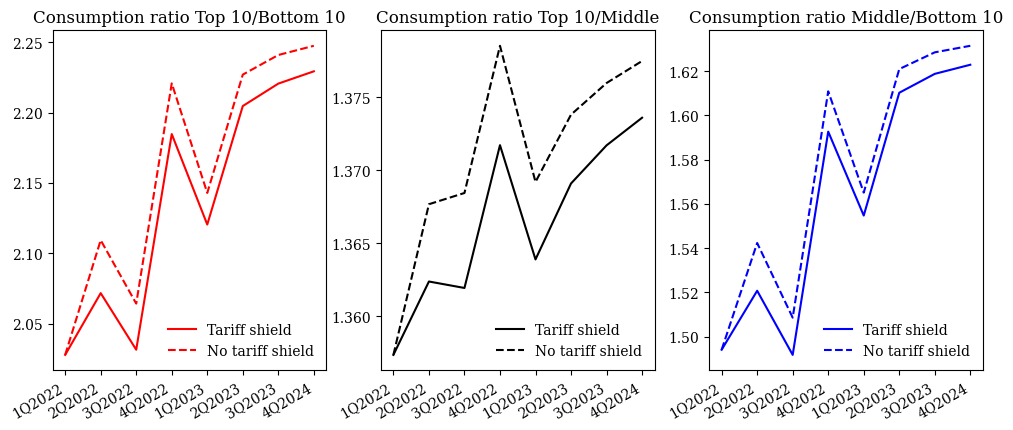

In [81]:
print('------ Figure 4: Inequalities (tariff shield) ------')
lab_dates = ['1Q2022', '2Q2022', '3Q2022', '4Q2022', '1Q2023', '2Q2023', '3Q2023', '4Q2024']
labs = ['Tariff shield', 'No tariff shield']
lab_titles = ['Consumption ratio Top 10/Bottom 10', 'Consumption ratio Top 10/Middle', 'Consumption ratio Middle/Bottom 10']

fig = plt.figure(figsize=(12,5))
ax = plt.subplot(131)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6],label=labs[0])
plt.plot(lab_dates,
         (built_C_5_nosubv[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_nosubv[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle='--',label=labs[1])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[0])
ax = plt.subplot(132)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3],label=labs[0])
plt.plot(lab_dates, 
         (built_C_5_nosubv[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_nosubv[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle='--',label=labs[1])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[1])
ax = plt.subplot(133)
plt.plot(lab_dates, 
         (built_C_3[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0],label=labs[0])
plt.plot(lab_dates, 
         (built_C_3_nosubv[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_nosubv[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle='--', label=labs[1])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[2])
fig.autofmt_xdate() 
if save_fig:
    plt.savefig('Figures/Figure4.eps', dpi=600)
plt.show()

In [82]:
# Save the benchmark inequalities
bench_ineq = np.array([(built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
              (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3[9:17]+stats_prod['Consumption'].iloc[3]),
              (built_C_3[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1])])
util.save_result(bench_ineq, 'Results/BenchmarkInequalities') 

In [83]:
level_nosubv_df['year'] = np.floor(level_nosubv_df.index)
print('---- Content for the tables (Tables 1, 5, 6, 7, 8, 9, 10, 11): No tariff shield row ----')
debt_2027 = level_nosubv_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_nosubv_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_nosubv_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_nosubv_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_nosubv_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_start = ineq_bench = ((built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]))[0]
ineq_bench = ((built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
ineq_alt   = ((built_C_5_nosubv[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_nosubv[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities pre-crisis: ', np.round(ineq_start, 2))
print('Consumption inequalities in 2024 (tariff shield): ', np.round(ineq_bench, 2))
print('Consumption inequalities in 2024 (no tariff shield): ', np.round(ineq_alt, 2))

---- Content for the tables (Tables 1, 5, 6, 7, 8, 9, 10, 11): No tariff shield row ----
Debt-to-GDP ratio (in 2027):  112.1 %
2022 GDP growth:  2.34 %
2023 GDP growth:  1.03 %
2022 inflation:  7.2 %
2023 inflation:  3.6 %
Consumption inequalities pre-crisis:  2.03
Consumption inequalities in 2024 (tariff shield):  2.23
Consumption inequalities in 2024 (no tariff shield):  2.25


### 7.3 No tariff shield in 2023

In [84]:
eps_hat_est_nosubv23 = eps_hat_est_df.copy()
eps_hat_est_nosubv23.iloc[14:18, -1] = 0

In [85]:
Ds_nosubv23 = fcst.reconstruct(new_M, np.array(eps_hat_est_nosubv23))

for (i, elem) in enumerate(new_outputs):
    globals()['built_%s_nosubv23' % elem] = Ds_nosubv23[:, i, :].sum(axis=1)

In [86]:
Y_level_nosubv23   = fcst.rebuild_level(built_Y_nosubv23, 'Output', len(built_Y_nosubv23), g=trend['Y'])
C_level_nosubv23   = fcst.rebuild_level(built_C_nosubv23, 'Consumption', len(built_C_nosubv23), g=trend['Y'])
w_level_nosubv23   = fcst.rebuild_level(built_w_nosubv23, 'Real wages', len(built_w_nosubv23))
L_level_nosubv23   = fcst.rebuild_level(built_L_nosubv23, 'Labor', len(built_L_nosubv23))
r_level_nosubv23   = fcst.rebuild_level(built_r_nosubv23, 'Real rate', None)
i_level_nosubv23   = fcst.rebuild_level(built_i_nosubv23, 'Nominal rate', None)
IPC_level_nosubv23 = fcst.rebuild_level(built_pi_nosubv23, 'Prices', len(built_pi_nosubv23))
Br_level_nosubv23  = fcst.rebuild_level(built_Br_nosubv23, 'Debt-to-GDP ratio', None)
E_level_nosubv23   = fcst.rebuild_level(built_E_nosubv23, 'Energy firm', len(built_E_nosubv23), g=trend['Y'])
YFE_level_nosubv23 = fcst.rebuild_level(built_YFE_nosubv23, 'Energy household', len(built_YFE_nosubv23), g=trend['Y'])

level_nosubv23_df  = pd.DataFrame(np.array([Y_level_nosubv23, IPC_level_nosubv23, C_level_nosubv23, w_level_nosubv23, L_level_nosubv23, r_level_nosubv23, i_level_nosubv23, Br_level_nosubv23, E_level_nosubv23, YFE_level_nosubv23]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

------ Figure of Appendix M: Tariff vs no tariff shield ------


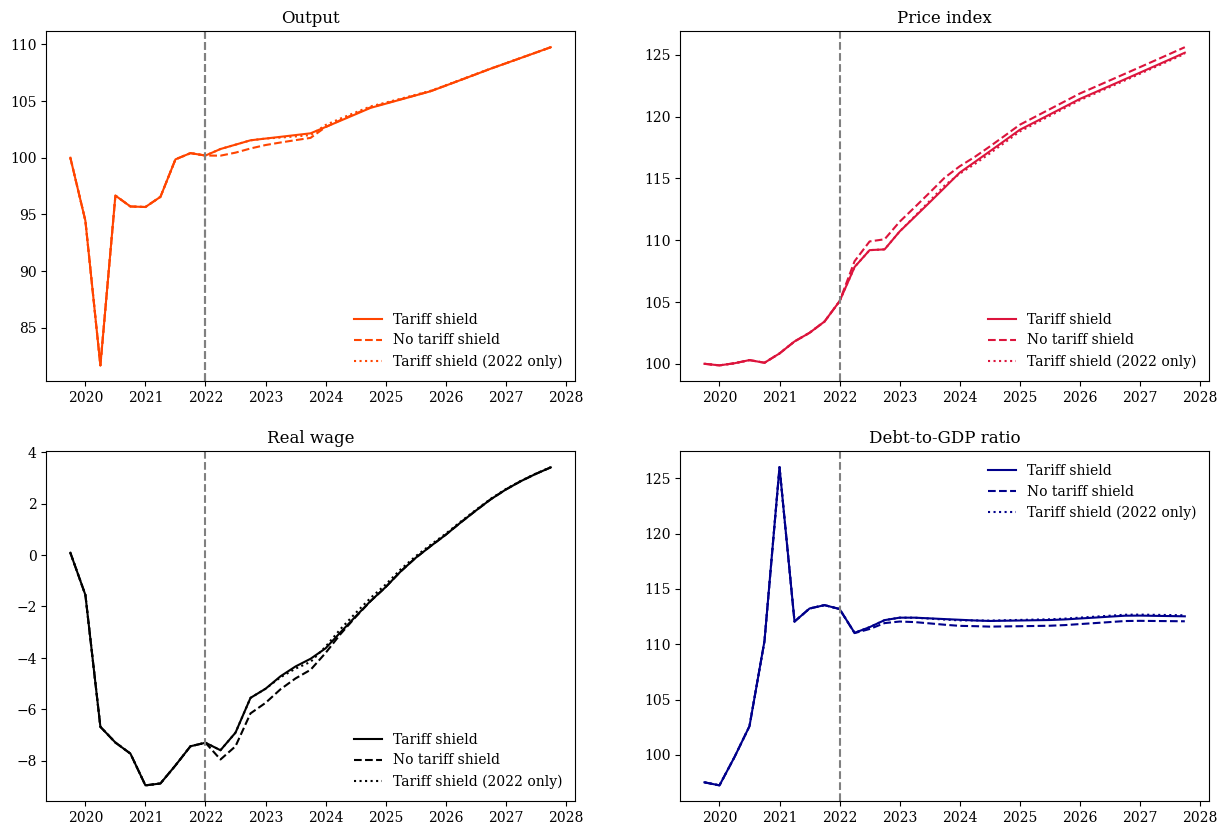

In [87]:
# Figure of Appendix M
print('------ Figure of Appendix M: Tariff vs no tariff shield ------')
fig, axs = plt.subplots(2,2, figsize=(15,10))

axs[0,0].plot(dates, level_df['Y'], color=outputs_info['Y']['color'], label='Tariff shield')
axs[0,0].plot(dates, level_nosubv_df['Y'], color=outputs_info['Y']['color'], linestyle='--', label='No tariff shield')
axs[0,0].plot(dates, level_nosubv23_df['Y'], color=outputs_info['Y']['color'], linestyle=':', label='Tariff shield (2022 only)')
axs[0,0].axvline(2022.0, color='grey', linestyle='--')
axs[0,0].axvline(2022.0, color='grey', linestyle='--')
axs[0,0].legend(frameon=False)
axs[0,0].set_title('Output')

axs[0,1].plot(dates, level_df['pi'], color=outputs_info['pi']['color'], label='Tariff shield')
axs[0,1].plot(dates, level_nosubv_df['pi'], color=outputs_info['pi']['color'], linestyle='--', label='No tariff shield')
axs[0,1].plot(dates, level_nosubv23_df['pi'], color=outputs_info['pi']['color'], linestyle=':', label='Tariff shield (2022 only)')
axs[0,1].axvline(2022.0, color='grey', linestyle='--')
axs[0,1].legend(frameon=False)
axs[0,1].set_title('Price index')

axs[1,0].plot(dates, level_df['w'], color=outputs_info['w']['color'], label='Tariff shield')
axs[1,0].plot(dates, level_nosubv_df['w'], color=outputs_info['w']['color'], linestyle='--', label='No tariff shield')
axs[1,0].plot(dates, level_nosubv23_df['w'], color=outputs_info['w']['color'], linestyle=':', label='Tariff shield (2022 only)')
axs[1,0].legend(frameon=False)
axs[1,0].axvline(2022.0, color='grey', linestyle='--')
axs[1,0].set_title('Real wage')

axs[1,1].plot(dates, level_df['Br'], color=outputs_info['Br']['color'], label='Tariff shield')
axs[1,1].plot(dates, level_nosubv_df['Br'], color=outputs_info['Br']['color'], linestyle='--', label='No tariff shield')
axs[1,1].plot(dates, level_nosubv23_df['Br'], color=outputs_info['Br']['color'], linestyle=':', label='Tariff shield (2022 only)')
axs[1,1].axvline(2022.0, color='grey', linestyle='--')
axs[1,1].legend(frameon=False)
axs[1,1].set_title('Debt-to-GDP ratio')

if save_fig:
    plt.savefig('Figures/AppendixM.eps', dpi=600)
plt.show()

In [88]:
ineq_Ds_nosubv23 = fcst.reconstruct(ineq_M, np.array(eps_hat_est_nosubv23))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_nosubv23' % (elem, i)] = ineq_Ds_nosubv23[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_nosubv23' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_nosubv23' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_nosubv23' % (elem, i)]))

In [89]:
level_nosubv23_df['year'] = np.floor(level_nosubv23_df.index)
print('---- Content for the tables (Table 5): Tariff shield row (only in 2022) ----')
debt_2027 = level_nosubv23_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_nosubv23_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_nosubv23_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_nosubv23_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_nosubv23_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_alt   = ((built_C_5_nosubv23[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_nosubv23[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities in 2024 (no tariff shield in 2023): ', np.round(ineq_alt, 2))

---- Content for the tables (Table 5): Tariff shield row (only in 2022) ----
Debt-to-GDP ratio (in 2027):  112.6 %
2022 GDP growth:  2.85 %
2023 GDP growth:  0.91 %
2022 inflation:  6.5 %
2023 inflation:  3.6 %
Consumption inequalities in 2024 (no tariff shield in 2023):  2.24


### 7.4 Transfers to compensate incompressible energy consumption

In [90]:
new_outputs_transfer = ['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE']

In [91]:
eps_hat_est_nosubv_conso = eps_hat_est_nosubv.copy()

incomp_subv = np.zeros(33)
incomp_subv[10:17] = built_incomp[10:17] / 2
eps_hat_est_nosubv_conso['Subv'] = incomp_subv

In [92]:
inputs_conso   = ['pFE', 'G', 'TransEXO', 'TaxEXO', 'mu', 'beta', 'subv', 'Subv']
sigmas['Subv'] = 1
rhos['Subv']   = inputs_info['Subv']['rho']

In [93]:
_, G_conso, _, _ = build_impulses(G_estim, inputs_conso, new_outputs_transfer, Tobs, inputs_info)
new_M_conso = fcst.generate_M(inputs_conso, new_outputs_transfer, sigmas, rhos, Tobs, G_conso)
new_Ds_conso = fcst.reconstruct(new_M_conso, np.array(eps_hat_est_nosubv_conso))

In [94]:
for (i, elem) in enumerate(new_outputs_transfer):
    globals()['built_%s_conso' % elem] = new_Ds_conso[:, i, :].sum(axis=1)

In [95]:
Y_level_conso   = fcst.rebuild_level(built_Y_conso, 'Output', len(built_Y_conso), g=trend['Y'])
C_level_conso   = fcst.rebuild_level(built_C_conso, 'Consumption', len(built_C_conso), g=trend['Y'])
w_level_conso   = fcst.rebuild_level(built_w_conso, 'Real wages', len(built_w_conso))
L_level_conso   = fcst.rebuild_level(built_L_conso, 'Labor', len(built_L_conso))
r_level_conso   = fcst.rebuild_level(built_r_conso, 'Real rate', None)
i_level_conso   = fcst.rebuild_level(built_i_conso, 'Nominal rate', None)
IPC_level_conso = fcst.rebuild_level(built_pi_conso, 'Prices', len(built_pi_conso))
Br_level_conso  = fcst.rebuild_level(built_Br_conso, 'Debt-to-GDP ratio', None)
E_level_conso   = fcst.rebuild_level(built_E_conso, 'Energy firm', len(built_E_conso), g=trend['Y'])
YFE_level_conso = fcst.rebuild_level(built_YFE_conso, 'Energy household', len(built_YFE_conso), g=trend['Y'])

level_conso_df  = pd.DataFrame(np.array([Y_level_conso, IPC_level_conso, C_level_conso, w_level_conso, L_level_conso, r_level_conso, i_level_conso, Br_level_conso, E_level_conso, YFE_level_conso]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

------ Figure of Appendix O: Subsidy to incompressible consumption ------


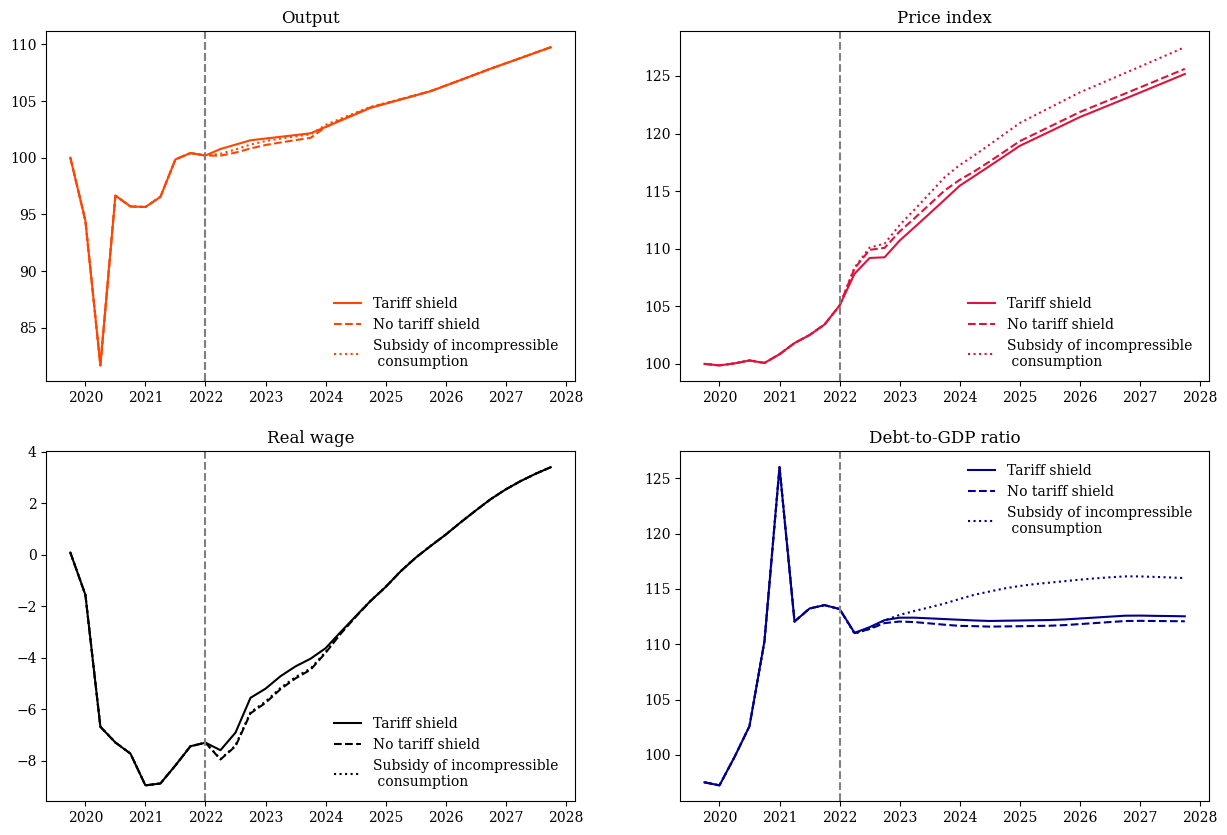

In [96]:
# Figure of Appendix O
print('------ Figure of Appendix O: Subsidy to incompressible consumption ------')
fig, axs = plt.subplots(2,2, figsize=(15,10))

axs[0,0].plot(dates, level_df['Y'], color=outputs_info['Y']['color'], label='Tariff shield')
axs[0,0].plot(dates, level_nosubv_df['Y'], color=outputs_info['Y']['color'], linestyle='--', label='No tariff shield')
axs[0,0].plot(dates, level_conso_df['Y'], color=outputs_info['Y']['color'], linestyle=':', label='Subsidy of incompressible \n consumption')
axs[0,0].axvline(2022.0, color='grey', linestyle='--')
axs[0,0].axvline(2022.0, color='grey', linestyle='--')
axs[0,0].legend(frameon=False)
axs[0,0].set_title('Output')

axs[0,1].plot(dates, level_df['pi'], color=outputs_info['pi']['color'], label='Tariff shield')
axs[0,1].plot(dates, level_nosubv_df['pi'], color=outputs_info['pi']['color'], linestyle='--', label='No tariff shield')
axs[0,1].plot(dates, level_conso_df['pi'], color=outputs_info['pi']['color'], linestyle=':', label='Subsidy of incompressible \n consumption')
axs[0,1].axvline(2022.0, color='grey', linestyle='--')
axs[0,1].legend(frameon=False)
axs[0,1].set_title('Price index')

axs[1,0].plot(dates, level_df['w'], color=outputs_info['w']['color'], label='Tariff shield')
axs[1,0].plot(dates, level_nosubv_df['w'], color=outputs_info['w']['color'], linestyle='--', label='No tariff shield')
axs[1,0].plot(dates, level_conso_df['w'], color=outputs_info['w']['color'], linestyle=':', label='Subsidy of incompressible \n consumption')
axs[1,0].legend(frameon=False)
axs[1,0].axvline(2022.0, color='grey', linestyle='--')
axs[1,0].set_title('Real wage')

axs[1,1].plot(dates, level_df['Br'], color=outputs_info['Br']['color'], label='Tariff shield')
axs[1,1].plot(dates, level_nosubv_df['Br'], color=outputs_info['Br']['color'], linestyle='--', label='No tariff shield')
axs[1,1].plot(dates, level_conso_df['Br'], color=outputs_info['Br']['color'], linestyle=':', label='Subsidy of incompressible \n consumption')
axs[1,1].axvline(2022.0, color='grey', linestyle='--')
axs[1,1].legend(frameon=False)
axs[1,1].set_title('Debt-to-GDP ratio')

if save_fig:
    plt.savefig('Figures/AppendixO.eps', dpi=600)
plt.show()

In [97]:
_, G_conso, _, _ = build_impulses(G_estim, inputs_conso, ineq_outputs, Tobs, inputs_info)
ineq_M_conso  = fcst.generate_M(inputs_conso, ineq_outputs, sigmas, rhos, Tobs, G_conso)
ineq_Ds_conso = fcst.reconstruct(ineq_M_conso, np.array(eps_hat_est_nosubv_conso))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_conso' % (elem, i)] = ineq_Ds_conso[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_conso' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_conso' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_conso' % (elem, i)]))

ineq_df_conso = pd.DataFrame(np.array([C_0_level_conso, C_1_level_conso, C_2_level_conso, C_3_level_conso, C_4_level_conso, C_5_level_conso, C_6_level_conso]).transpose(),
                      index=datas_df.index, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

In [98]:
level_conso_df['year'] = np.floor(level_conso_df.index)
print('---- Content for the tables (Tables 1 and 6): Transfer / Subsidy to the incompressible consumption row ----')
debt_2027 = level_conso_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_conso_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_conso_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_conso_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_conso_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_alt   = ((built_C_5_conso[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_conso[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities in 2024 (energy subsidy): ', np.round(ineq_alt, 2))

---- Content for the tables (Tables 1 and 6): Transfer / Subsidy to the incompressible consumption row ----
Debt-to-GDP ratio (in 2027):  116.1 %
2022 GDP growth:  2.54 %
2023 GDP growth:  1.16 %
2022 inflation:  7.4 %
2023 inflation:  4.3 %
Consumption inequalities in 2024 (energy subsidy):  2.1


### 7.5 Wage indexation

In [99]:
ss_wage = ss.copy()
ss_wage['kappaw'] = 5 * ss['kappaw']

%time G_wagech = model.solve_jacobian(ss_wage, unknowns=unknowns, targets=targets, inputs=exogenous_estim+['subv', 'Subv'], T=T_estim)

CPU times: user 4.85 s, sys: 2.2 s, total: 7.05 s
Wall time: 1.19 s


In [100]:
_, G_wage, rhos, sigmas = build_impulses(G_wagech, inputs, outputs, Tobs, inputs_info)

In [101]:
M_wage = fcst.generate_M(inputs, outputs, sigmas, rhos, Tobs, G_wage)

In [102]:
eps_hat_est_wage_covid, Ds_wage_covid = back_out_shocks(M_wage, np.array(datas_df)[:10, :], preperiods=0)

In [103]:
eps_hat_est_wage = pd.DataFrame(np.vstack([eps_hat_est_wage_covid, np.array(eps_hat_est_df)[10:, :]]), index=eps_hat_est_df.index,
                                columns=eps_hat_est_df.columns)

In [104]:
new_outputs = ['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE']

In [105]:
_, G_wage, _, _ = build_impulses(G_wagech, inputs, new_outputs, Tobs, inputs_info)

In [106]:
new_M      = fcst.generate_M(inputs, new_outputs, sigmas, rhos, Tobs, G)
new_M_wage = fcst.generate_M(inputs, new_outputs, sigmas, rhos, Tobs, G_wage)

In [107]:
new_Ds      = fcst.reconstruct(new_M, np.array(eps_hat_est))
new_Ds_wage = fcst.reconstruct(new_M_wage, np.array(eps_hat_est_wage))

In [108]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s_wage' % elem] = new_Ds_wage[:, i, :].sum(axis=1)

In [109]:
Y_level_wage   = fcst.rebuild_level(built_Y_wage, 'Output', len(built_Y_wage), g=trend['Y'])
C_level_wage   = fcst.rebuild_level(built_C_wage, 'Consumption', len(built_C_wage), g=trend['Y'])
w_level_wage   = fcst.rebuild_level(built_w_wage, 'Real wages', len(built_w_wage))
L_level_wage   = fcst.rebuild_level(built_L_wage, 'Labor', len(built_L_wage))
r_level_wage   = fcst.rebuild_level(built_r_wage, 'Real rate', None)
i_level_wage   = fcst.rebuild_level(built_i_wage, 'Nominal rate', None)
IPC_level_wage = fcst.rebuild_level(built_pi_wage, 'Prices', len(built_pi_wage))
Br_level_wage  = fcst.rebuild_level(built_Br_wage, 'Debt-to-GDP ratio', None)
E_level_wage   = fcst.rebuild_level(built_E_wage, 'Energy firm', len(built_E_wage), g=trend['Y'])
YFE_level_wage = fcst.rebuild_level(built_YFE_wage, 'Energy household', len(built_YFE_wage), g=trend['Y'])

level_wage_df  = pd.DataFrame(np.array([Y_level_wage, IPC_level_wage, C_level_wage, w_level_wage, L_level_wage, r_level_wage, i_level_wage, Br_level_wage, E_level_wage, YFE_level_wage]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

------ Figure of Appendix N: Wage indexation ------


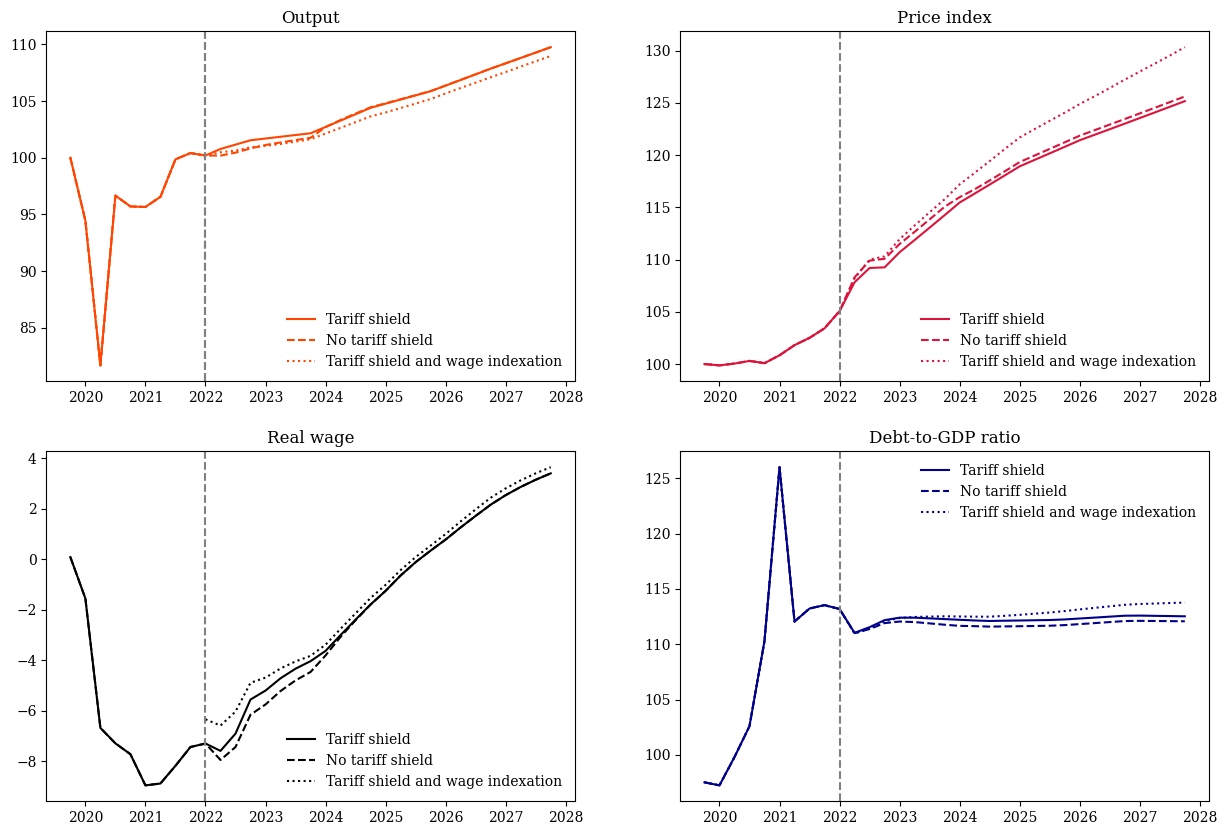

In [110]:
# Figure of Appendix N
print('------ Figure of Appendix N: Wage indexation ------')
fig, axs = plt.subplots(2,2, figsize=(15,10))

axs[0,0].plot(dates, level_df['Y'], color=outputs_info['Y']['color'], label='Tariff shield')
axs[0,0].plot(dates, level_nosubv_df['Y'], color=outputs_info['Y']['color'], linestyle='--', label='No tariff shield')
axs[0,0].plot(dates, level_wage_df['Y'], color=outputs_info['Y']['color'], linestyle=':', label='Tariff shield and wage indexation')
axs[0,0].axvline(2022.0, color='grey', linestyle='--')
axs[0,0].axvline(2022.0, color='grey', linestyle='--')
axs[0,0].legend(frameon=False)
axs[0,0].set_title('Output')

axs[0,1].plot(dates, level_df['pi'], color=outputs_info['pi']['color'], label='Tariff shield')
axs[0,1].plot(dates, level_nosubv_df['pi'], color=outputs_info['pi']['color'], linestyle='--', label='No tariff shield')
axs[0,1].plot(dates, level_wage_df['pi'], color=outputs_info['pi']['color'], linestyle=':', label='Tariff shield and wage indexation')
axs[0,1].axvline(2022.0, color='grey', linestyle='--')
axs[0,1].legend(frameon=False)
axs[0,1].set_title('Price index')

axs[1,0].plot(dates, level_df['w'], color=outputs_info['w']['color'], label='Tariff shield')
axs[1,0].plot(dates, level_nosubv_df['w'], color=outputs_info['w']['color'], linestyle='--', label='No tariff shield')
axs[1,0].plot(dates, [None]*9 + list(level_wage_df['w'])[9:], color=outputs_info['w']['color'], linestyle=':', label='Tariff shield and wage indexation')
axs[1,0].legend(frameon=False)
axs[1,0].axvline(2022.0, color='grey', linestyle='--')
axs[1,0].set_title('Real wage')

axs[1,1].plot(dates, level_df['Br'], color=outputs_info['Br']['color'], label='Tariff shield')
axs[1,1].plot(dates, level_nosubv_df['Br'], color=outputs_info['Br']['color'], linestyle='--', label='No tariff shield')
axs[1,1].plot(dates, level_wage_df['Br'], color=outputs_info['Br']['color'], linestyle=':', label='Tariff shield and wage indexation')
axs[1,1].axvline(2022.0, color='grey', linestyle='--')
axs[1,1].legend(frameon=False)
axs[1,1].set_title('Debt-to-GDP ratio')

if save_fig:
    plt.savefig('Figures/AppendixN.eps', dpi=600)
plt.show()

In [111]:
_, G_ineq, _, _ = build_impulses(G_wagech, inputs, ineq_outputs, Tobs, inputs_info)
ineq_M_wage  = fcst.generate_M(inputs, ineq_outputs, sigmas, rhos, Tobs, G_ineq)
ineq_Ds_wage = fcst.reconstruct(ineq_M_wage, np.array(eps_hat_est_wage))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_wage' % (elem, i)] = ineq_Ds_wage[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_wage' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_wage' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_wage' % (elem, i)]))

ineq_df_wage = pd.DataFrame(np.array([C_0_level_wage, C_1_level_wage, C_2_level_wage, C_3_level_wage, C_4_level_wage, C_5_level_wage, C_6_level_wage]).transpose(),
                      index=datas_df.index, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

------ Figure 8: Inequalities (wage indexation) ------


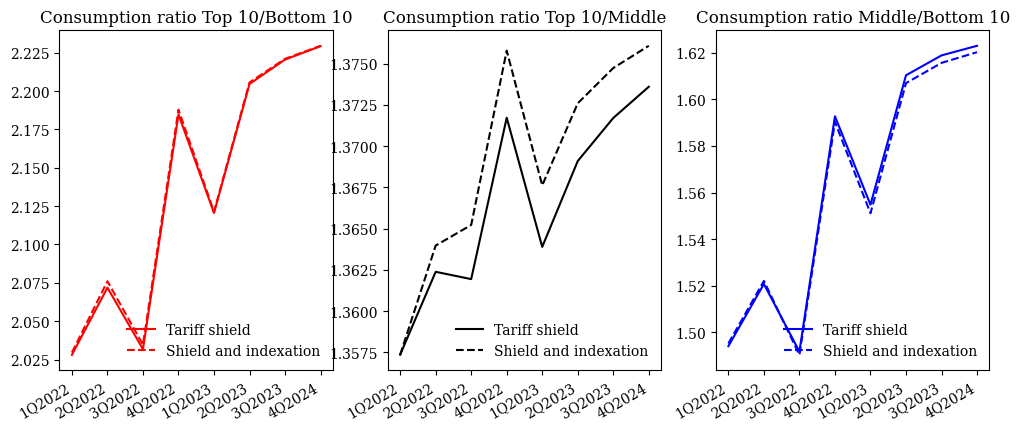

In [112]:
print('------ Figure 8: Inequalities (wage indexation) ------')
lab_dates = ['1Q2022', '2Q2022', '3Q2022', '4Q2022', '1Q2023', '2Q2023', '3Q2023', '4Q2024']
labs = ['Tariff shield', 'Shield and indexation']
lab_titles = ['Consumption ratio Top 10/Bottom 10', 'Consumption ratio Top 10/Middle', 'Consumption ratio Middle/Bottom 10']

fig = plt.figure(figsize=(12,5))
ax = plt.subplot(131)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6],label=labs[0])
plt.plot(lab_dates,
         (built_C_5_wage[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_wage[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle='--',label=labs[1])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[0])
ax = plt.subplot(132)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3],label=labs[0])
plt.plot(lab_dates, 
         (built_C_5_wage[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_wage[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle='--',label=labs[1])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[1])
ax = plt.subplot(133)
plt.plot(lab_dates, 
         (built_C_3[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0],label=labs[0])
plt.plot(lab_dates, 
         (built_C_3_wage[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_wage[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle='--', label=labs[1])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[2])
fig.autofmt_xdate() 
if save_fig:
    plt.savefig('Figures/Figure8.eps', dpi=600)
plt.show()

In [113]:
level_wage_df['year'] = np.floor(level_wage_df.index)
print('---- Content for the tables (Tables 1 and 8): Tariff shield and wage indexation row ----')
debt_2027 = level_wage_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_wage_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_wage_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_wage_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_wage_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_alt   = ((built_C_5_wage[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_wage[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities in 2024 (tariff shield + wage): ', np.round(ineq_alt, 2))

---- Content for the tables (Tables 1 and 8): Tariff shield and wage indexation row ----
Debt-to-GDP ratio (in 2027):  113.7 %
2022 GDP growth:  2.48 %
2023 GDP growth:  0.76 %
2022 inflation:  7.3 %
2023 inflation:  4.1 %
Consumption inequalities in 2024 (tariff shield + wage):  2.23


### 7.6 Wage indexation but no tariff shield

In [114]:
eps_hat_est_wage_nosubv = pd.DataFrame(np.vstack([eps_hat_est_wage_covid, np.array(eps_hat_est_nosubv)[10:, :]]), index=eps_hat_est_df.index,
                                columns=eps_hat_est_df.columns)

In [115]:
Ds_wage_nosubv = fcst.reconstruct(new_M_wage, np.array(eps_hat_est_wage_nosubv))

In [116]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s_wage_nosubv' % elem] = Ds_wage_nosubv[:, i, :].sum(axis=1)

In [117]:
Y_level_wage_nosubv   = fcst.rebuild_level(built_Y_wage_nosubv, 'Output', len(built_Y_wage_nosubv), g=trend['Y'])
C_level_wage_nosubv   = fcst.rebuild_level(built_C_wage_nosubv, 'Consumption', len(built_C_wage_nosubv), g=trend['Y'])
w_level_wage_nosubv   = fcst.rebuild_level(built_w_wage_nosubv, 'Real wages', len(built_w_wage_nosubv))
L_level_wage_nosubv   = fcst.rebuild_level(built_L_wage_nosubv, 'Labor', len(built_L_wage_nosubv))
r_level_wage_nosubv   = fcst.rebuild_level(built_r_wage_nosubv, 'Real rate', None)
i_level_wage_nosubv   = fcst.rebuild_level(built_i_wage_nosubv, 'Nominal rate', None)
IPC_level_wage_nosubv = fcst.rebuild_level(built_pi_wage_nosubv, 'Prices', len(built_pi_wage_nosubv))
Br_level_wage_nosubv  = fcst.rebuild_level(built_Br_wage_nosubv, 'Debt-to-GDP ratio', None)
E_level_wage_nosubv   = fcst.rebuild_level(built_E_wage_nosubv, 'Energy firm', len(built_E_wage_nosubv), g=trend['Y'])
YFE_level_wage_nosubv = fcst.rebuild_level(built_YFE_wage_nosubv, 'Energy household', len(built_YFE_wage_nosubv), g=trend['Y'])

In [118]:
level_wage_nosubv_df  = pd.DataFrame(np.array([Y_level_wage_nosubv, IPC_level_wage_nosubv, C_level_wage_nosubv, w_level_wage_nosubv, L_level_wage_nosubv, r_level_wage_nosubv, i_level_wage_nosubv, Br_level_wage_nosubv, E_level_wage_nosubv, YFE_level_wage_nosubv]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

In [119]:
level_wage_nosubv_df['year'] = np.floor(level_wage_nosubv_df.index)
print('---- Content for the tables (Table 8): No tariff shield and wage indexation row ----')
debt_2027 = level_wage_nosubv_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_wage_nosubv_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_wage_nosubv_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_wage_nosubv_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_wage_nosubv_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')

---- Content for the tables (Table 8): No tariff shield and wage indexation row ----
Debt-to-GDP ratio (in 2027):  113.2 %
2022 GDP growth:  2.01 %
2023 GDP growth:  0.77 %
2022 inflation:  7.9 %
2023 inflation:  4.2 %


### 7.7 Alternative transfer policy

Instead of transfering x/household to everyone, which implies a total cost x, we transfer 2x to the bottom 30% of the distribution only. This represents a total cost of 0.6x (40% lower).

In [120]:
eps_hat_est_nosubv_conso_b30 = eps_hat_est_nosubv_conso.copy()

eps_hat_est_nosubv_conso_b30.rename(columns={'Subv': 'Subv2'}, inplace=True)
eps_hat_est_nosubv_conso_b30['Subv2'] = np.array(eps_hat_est_nosubv_conso['Subv'] * 0.6)

In [121]:
inputs_conso_b30   = ['pFE', 'G', 'TransEXO', 'TaxEXO', 'mu', 'beta', 'subv', 'Subv2']
sigmas['Subv2']    = 1
rhos['Subv2']      = inputs_info['Subv2']['rho']

In [122]:
_, G_conso_b30, _, _ = build_impulses(G_estim, inputs_conso_b30, new_outputs_transfer, Tobs, inputs_info)
new_M_conso_b30 = fcst.generate_M(inputs_conso_b30, new_outputs_transfer, sigmas, rhos, Tobs, G_conso_b30)
new_Ds_conso_b30 = fcst.reconstruct(new_M_conso_b30, np.array(eps_hat_est_nosubv_conso_b30))

In [123]:
for (i, elem) in enumerate(new_outputs_transfer):
    globals()['built_%s_conso_b30' % elem] = new_Ds_conso_b30[:, i, :].sum(axis=1)

In [124]:
Y_level_conso_b30   = fcst.rebuild_level(built_Y_conso_b30, 'Output', len(built_Y_conso_b30), g=trend['Y'])
C_level_conso_b30   = fcst.rebuild_level(built_C_conso_b30, 'Consumption', len(built_C_conso_b30), g=trend['Y'])
w_level_conso_b30   = fcst.rebuild_level(built_w_conso_b30, 'Real wages', len(built_w_conso_b30))
L_level_conso_b30   = fcst.rebuild_level(built_L_conso_b30, 'Labor', len(built_L_conso_b30))
r_level_conso_b30   = fcst.rebuild_level(built_r_conso_b30, 'Real rate', None)
i_level_conso_b30   = fcst.rebuild_level(built_i_conso_b30, 'Nominal rate', None)
IPC_level_conso_b30 = fcst.rebuild_level(built_pi_conso_b30, 'Prices', len(built_pi_conso_b30))
Br_level_conso_b30  = fcst.rebuild_level(built_Br_conso_b30, 'Debt-to-GDP ratio', None)
E_level_conso_b30   = fcst.rebuild_level(built_E_conso_b30, 'Energy firm', len(built_E_conso_b30), g=trend['Y'])
YFE_level_conso_b30 = fcst.rebuild_level(built_YFE_conso_b30, 'Energy household', len(built_YFE_conso_b30), g=trend['Y'])

level_conso_b30_df  = pd.DataFrame(np.array([Y_level_conso_b30, IPC_level_conso_b30, C_level_conso_b30, w_level_conso_b30, L_level_conso_b30, r_level_conso_b30, i_level_conso_b30, Br_level_conso_b30, E_level_conso_b30, YFE_level_conso_b30]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

In [125]:
_, G_conso_b30, _, _ = build_impulses(G_estim, inputs_conso_b30, ineq_outputs, Tobs, inputs_info)
ineq_M_conso_b30  = fcst.generate_M(inputs_conso_b30, ineq_outputs, sigmas, rhos, Tobs, G_conso_b30)
ineq_Ds_conso_b30 = fcst.reconstruct(ineq_M_conso_b30, np.array(eps_hat_est_nosubv_conso_b30))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_conso_b30' % (elem, i)] = ineq_Ds_conso_b30[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_conso_b30' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_conso_b30' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_conso_b30' % (elem, i)]))

ineq_df_conso_b30 = pd.DataFrame(np.array([C_0_level_conso_b30, C_1_level_conso_b30, C_2_level_conso_b30, C_3_level_conso_b30, C_4_level_conso_b30, C_5_level_conso_b30, C_6_level_conso_b30]).transpose(),
                      index=datas_df.index, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])


------ Figure 6: Inequalities (redistribution) ------


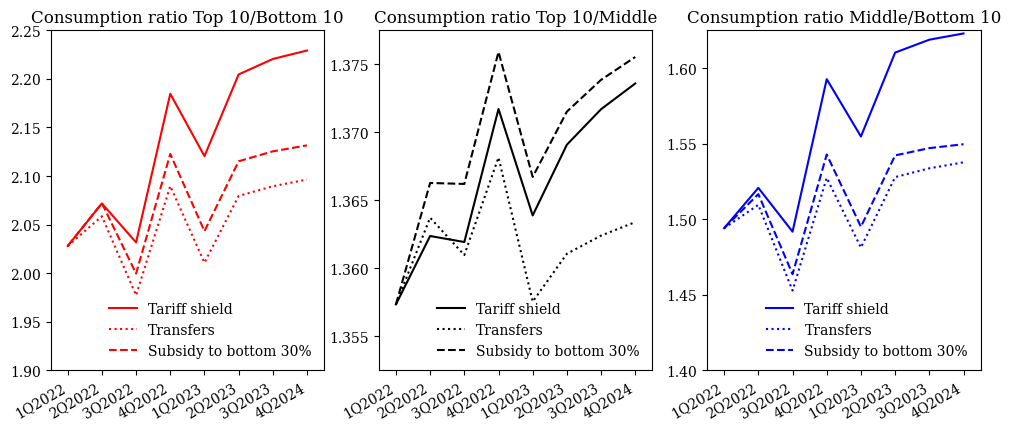

In [126]:
print('------ Figure 6: Inequalities (redistribution) ------')
lab_dates = ['1Q2022', '2Q2022', '3Q2022', '4Q2022', '1Q2023', '2Q2023', '3Q2023', '4Q2024']
labs = ['Tariff shield', 'Transfers', 'Subsidy to bottom 30%']
lab_titles = ['Consumption ratio Top 10/Bottom 10', 'Consumption ratio Top 10/Middle', 'Consumption ratio Middle/Bottom 10']

fig = plt.figure(figsize=(12,5))
ax = plt.subplot(131)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6],label=labs[0])
plt.plot(lab_dates,
         (built_C_5_conso[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_conso[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle=':',label=labs[1])
plt.plot(lab_dates,
         (built_C_5_conso_b30[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_conso_b30[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle='--',label=labs[2])
ax.legend(loc='lower right', frameon=False)
plt.axis([-0.5, 7.5, 1.9, 2.25])
plt.title(lab_titles[0])
ax = plt.subplot(132)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3],label=labs[0])
plt.plot(lab_dates, 
         (built_C_5_conso[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_conso[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle=':',label=labs[1])
plt.plot(lab_dates, 
         (built_C_5_conso_b30[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_conso_b30[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle='--',label=labs[2])
ax.legend(loc='lower right', frameon=False)
plt.axis([-0.5, 7.5, 1.3525, 1.3775])
plt.title(lab_titles[1])
ax = plt.subplot(133)
plt.plot(lab_dates, 
         (built_C_3[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0],label=labs[0])
plt.plot(lab_dates, 
         (built_C_3_conso[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_conso[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle=':', label=labs[1])
plt.plot(lab_dates, 
         (built_C_3_conso_b30[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_conso_b30[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle='--', label=labs[2])
ax.legend(loc='lower right', frameon=False)
plt.axis([-0.5, 7.5, 1.4, 1.625])
plt.title(lab_titles[2])
fig.autofmt_xdate() 
if save_fig:
    plt.savefig('Figures/Figure6.eps', dpi=600)
plt.show()


In [127]:
level_conso_b30_df['year'] = np.floor(level_conso_b30_df.index)
print('---- Content for the tables (Tables 6 and 9): Targeted subsidies & benchmark Taylor rule row ----')
debt_2027 = level_conso_b30_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_conso_b30_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_conso_b30_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_conso_b30_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_conso_b30_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_alt   = ((built_C_5_conso_b30[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_conso_b30[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities in 2024 (energy subsidy): ', np.round(ineq_alt, 2))

---- Content for the tables (Tables 6 and 9): Targeted subsidies & benchmark Taylor rule row ----
Debt-to-GDP ratio (in 2027):  114.6 %
2022 GDP growth:  2.82 %
2023 GDP growth:  1.43 %
2022 inflation:  7.5 %
2023 inflation:  4.5 %
Consumption inequalities in 2024 (energy subsidy):  2.13


### 7.8 Distortionary labor tax

In [128]:
ss_taul = ss.copy()
ss_taul['χl'] = 1

In [129]:
%time G_taulch = model.solve_jacobian(ss_taul, unknowns=unknowns, targets=targets, inputs=exogenous_estim+['subv'], T=T_estim)

CPU times: user 4 s, sys: 2.57 s, total: 6.57 s
Wall time: 1.07 s


In [130]:
_, G_taul, rhos, sigmas = build_impulses(G_taulch, inputs, outputs, Tobs, inputs_info)

In [131]:
M_taul = fcst.generate_M(inputs, outputs, sigmas, rhos, Tobs, G_taul)

In [132]:
eps_hat_est_taul_covid, Ds_taul_covid = back_out_shocks(M_taul, np.array(datas_df)[:10, :], preperiods=0)

In [133]:
eps_hat_est_taul = pd.DataFrame(np.vstack([eps_hat_est_taul_covid, np.array(eps_hat_est_df)[10:, :]]), index=eps_hat_est_df.index,
                                columns=eps_hat_est_df.columns)

In [134]:
inputs_taul = inputs.copy()

In [135]:
new_outputs_taul = ['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE', 'taul', 'tauc']
_, G_taul, rhos, sigmas = build_impulses(G_taulch, inputs_taul, new_outputs_taul, Tobs, inputs_info)

In [136]:
new_M_taul = fcst.generate_M(inputs_taul, new_outputs_taul, sigmas, rhos, Tobs, G_taul)
new_Ds_taul = fcst.reconstruct(new_M_taul, np.array(eps_hat_est_taul))

In [137]:
for (i, elem) in enumerate(new_outputs_taul):
    globals()['built_%s_taul' % elem] = new_Ds_taul[:, i, :].sum(axis=1)

In [138]:
Y_level_taul   = fcst.rebuild_level(built_Y_taul, 'Output', len(built_Y_taul), g=trend['Y'])
C_level_taul   = fcst.rebuild_level(built_C_taul, 'Consumption', len(built_C_taul), g=trend['Y'])
w_level_taul   = fcst.rebuild_level(built_w_taul, 'Real wages', len(built_w_taul))
L_level_taul   = fcst.rebuild_level(built_L_taul, 'Labor', len(built_L_taul))
r_level_taul   = fcst.rebuild_level(built_r_taul, 'Real rate', None)
i_level_taul   = fcst.rebuild_level(built_i_taul, 'Nominal rate', None)
IPC_level_taul = fcst.rebuild_level(built_pi_taul, 'Prices', len(built_pi_taul))
Br_level_taul  = fcst.rebuild_level(built_Br_taul, 'Debt-to-GDP ratio', None)
E_level_taul   = fcst.rebuild_level(built_E_taul, 'Energy firm', len(built_E_taul), g=trend['Y'])
YFE_level_taul = fcst.rebuild_level(built_YFE_taul, 'Energy household', len(built_YFE_taul), g=trend['Y'])

level_taul_df  = pd.DataFrame(np.array([Y_level_taul, IPC_level_taul, C_level_taul, w_level_taul, L_level_taul, r_level_taul, i_level_taul, Br_level_taul, E_level_taul, YFE_level_taul]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

In [139]:
_, G_ineq, _, _ = build_impulses(G_taulch, inputs, ineq_outputs, Tobs, inputs_info)
ineq_M_taul  = fcst.generate_M(inputs, ineq_outputs, sigmas, rhos, Tobs, G_ineq)
ineq_Ds_taul = fcst.reconstruct(ineq_M_taul, np.array(eps_hat_est_taul))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_taul' % (elem, i)] = ineq_Ds_taul[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_taul' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_taul' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_taul' % (elem, i)]))

ineq_df_taul = pd.DataFrame(np.array([C_0_level_taul, C_1_level_taul, C_2_level_taul, C_3_level_taul, C_4_level_taul, C_5_level_taul, C_6_level_taul]).transpose(),
                      index=datas_df.index, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

In [140]:
level_taul_df['year'] = np.floor(level_taul_df.index)
print('---- Content for the tables (Table 7): Tariff shield and distorsive labor tax row ----')
debt_2027 = level_taul_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_taul_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_taul_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_taul_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_taul_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_alt   = ((built_C_5_taul[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_taul[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities in 2024 (tariff shield + labor tax): ', np.round(ineq_alt, 2))

---- Content for the tables (Table 7): Tariff shield and distorsive labor tax row ----
Debt-to-GDP ratio (in 2027):  111.9 %
2022 GDP growth:  2.67 %
2023 GDP growth:  0.94 %
2022 inflation:  6.6 %
2023 inflation:  3.6 %
Consumption inequalities in 2024 (tariff shield + labor tax):  2.24


### 7.9 Distortionary consumption tax

In [141]:
ss_tauc = ss.copy()
ss_tauc['χc'] = 1

In [142]:
%time G_taucch = model.solve_jacobian(ss_tauc, unknowns=unknowns, targets=targets, inputs=exogenous_estim+['subv'], T=T_estim)

CPU times: user 3.86 s, sys: 1.64 s, total: 5.5 s
Wall time: 935 ms


In [143]:
_, G_tauc, rhos, sigmas = build_impulses(G_taucch, inputs, outputs, Tobs, inputs_info)

In [144]:
M_tauc = fcst.generate_M(inputs, outputs, sigmas, rhos, Tobs, G_tauc)

In [145]:
eps_hat_est_tauc_covid, Ds_tauc_covid = back_out_shocks(M_tauc, np.array(datas_df)[:10, :], preperiods=0)

In [146]:
eps_hat_est_tauc = pd.DataFrame(np.vstack([eps_hat_est_tauc_covid, np.array(eps_hat_est_df)[10:, :]]), index=eps_hat_est_df.index,
                                columns=eps_hat_est_df.columns)

In [147]:
inputs_tauc = inputs.copy()

In [148]:
new_outputs_tauc = ['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE', 'taul', 'tauc']
_, G_tauc, rhos, sigmas = build_impulses(G_taucch, inputs_tauc, new_outputs_tauc, Tobs, inputs_info)

In [149]:
new_M_tauc = fcst.generate_M(inputs_tauc, new_outputs_tauc, sigmas, rhos, Tobs, G_tauc)
new_Ds_tauc = fcst.reconstruct(new_M_tauc, np.array(eps_hat_est_tauc))

In [150]:
for (i, elem) in enumerate(new_outputs_tauc):
    globals()['built_%s_tauc' % elem] = new_Ds_tauc[:, i, :].sum(axis=1)

In [151]:
Y_level_tauc   = fcst.rebuild_level(built_Y_tauc, 'Output', len(built_Y_tauc), g=trend['Y'])
C_level_tauc   = fcst.rebuild_level(built_C_tauc, 'Consumption', len(built_C_tauc), g=trend['Y'])
w_level_tauc   = fcst.rebuild_level(built_w_tauc, 'Real wages', len(built_w_tauc))
L_level_tauc   = fcst.rebuild_level(built_L_tauc, 'Labor', len(built_L_tauc))
r_level_tauc   = fcst.rebuild_level(built_r_tauc, 'Real rate', None)
i_level_tauc   = fcst.rebuild_level(built_i_tauc, 'Nominal rate', None)
IPC_level_tauc = fcst.rebuild_level(built_pi_tauc, 'Prices', len(built_pi_tauc))
Br_level_tauc  = fcst.rebuild_level(built_Br_tauc, 'Debt-to-GDP ratio', None)
E_level_tauc   = fcst.rebuild_level(built_E_tauc, 'Energy firm', len(built_E_tauc), g=trend['Y'])
YFE_level_tauc = fcst.rebuild_level(built_YFE_tauc, 'Energy household', len(built_YFE_tauc), g=trend['Y'])

level_tauc_df  = pd.DataFrame(np.array([Y_level_tauc, IPC_level_tauc, C_level_tauc, w_level_tauc, L_level_tauc, r_level_tauc, i_level_tauc, Br_level_tauc, E_level_tauc, YFE_level_tauc]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

In [152]:
_, G_ineq, _, _ = build_impulses(G_taucch, inputs, ineq_outputs, Tobs, inputs_info)
ineq_M_tauc  = fcst.generate_M(inputs, ineq_outputs, sigmas, rhos, Tobs, G_ineq)
ineq_Ds_tauc = fcst.reconstruct(ineq_M_tauc, np.array(eps_hat_est_tauc))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_tauc' % (elem, i)] = ineq_Ds_tauc[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_tauc' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_tauc' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_tauc' % (elem, i)]))

ineq_df_tauc = pd.DataFrame(np.array([C_0_level_tauc, C_1_level_tauc, C_2_level_tauc, C_3_level_tauc, C_4_level_tauc, C_5_level_tauc, C_6_level_tauc]).transpose(),
                      index=datas_df.index, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

In [153]:
level_tauc_df['year'] = np.floor(level_tauc_df.index)
print('---- Content for the tables (Tables 1 and 7): Tariff shield and distorsive consumption tax row ----')
debt_2027 = level_tauc_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_tauc_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_tauc_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_tauc_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_tauc_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_alt   = ((built_C_5_tauc[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_tauc[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities in 2024 (tariff shield + consumption tax): ', np.round(ineq_alt, 2))

---- Content for the tables (Tables 1 and 7): Tariff shield and distorsive consumption tax row ----
Debt-to-GDP ratio (in 2027):  111.8 %
2022 GDP growth:  2.37 %
2023 GDP growth:  1.14 %
2022 inflation:  6.2 %
2023 inflation:  3.2 %
Consumption inequalities in 2024 (tariff shield + consumption tax):  2.25


In [154]:
_, G_ineq, _, _ = build_impulses(G_taucch, inputs, ineq_outputs, Tobs, inputs_info)
ineq_M_tauc1  = fcst.generate_M(inputs, ineq_outputs, sigmas, rhos, Tobs, G_ineq)
ineq_Ds_tauc1 = fcst.reconstruct(ineq_M_tauc1, np.array(eps_hat_est_tauc))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_tauc1' % (elem, i)] = ineq_Ds_tauc1[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_tauc1' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_tauc1' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_tauc1' % (elem, i)]))

ineq_df_tauc1 = pd.DataFrame(np.array([C_0_level_tauc1, C_1_level_tauc1, C_2_level_tauc1, C_3_level_tauc1, C_4_level_tauc1, C_5_level_tauc1, C_6_level_tauc1]).transpose(),
                      index=datas_df.index, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

------ Figure 7: Inequalities (distorsive taxes) ------


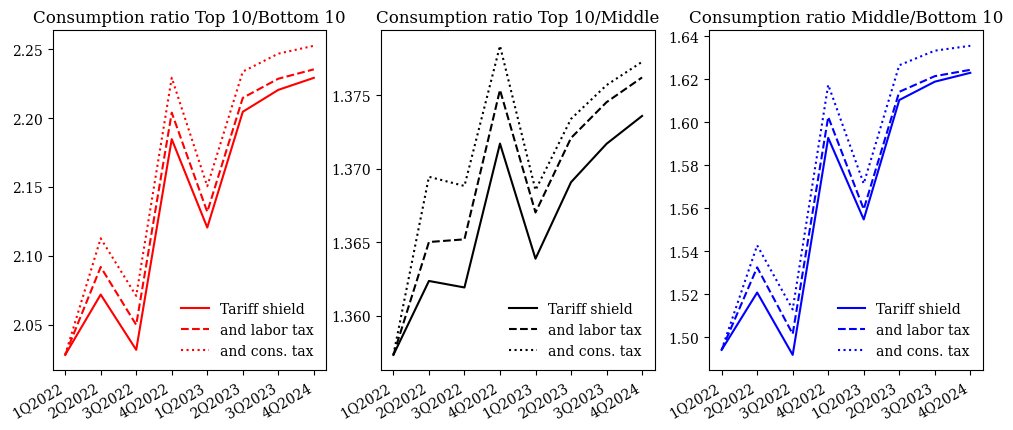

In [155]:
print('------ Figure 7: Inequalities (distorsive taxes) ------')
lab_dates = ['1Q2022', '2Q2022', '3Q2022', '4Q2022', '1Q2023', '2Q2023', '3Q2023', '4Q2024']
labs = ['Tariff shield', 'and labor tax', 'and cons. tax']
lab_titles = ['Consumption ratio Top 10/Bottom 10', 'Consumption ratio Top 10/Middle', 'Consumption ratio Middle/Bottom 10']

fig = plt.figure(figsize=(12,5))
ax = plt.subplot(131)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6],label=labs[0])
plt.plot(lab_dates, 
         (built_C_5_taul[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_taul[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle='--',label=labs[1])
plt.plot(lab_dates,
         (built_C_5_tauc[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_tauc[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle=':',label=labs[2])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[0])
ax = plt.subplot(132)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3],label=labs[0])
plt.plot(lab_dates, 
         (built_C_5_taul[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_taul[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle='--',label=labs[1])
plt.plot(lab_dates, 
         (built_C_5_tauc[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_tauc[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle=':',label=labs[2])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[1])
ax = plt.subplot(133)
plt.plot(lab_dates, 
         (built_C_3[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0],label=labs[0])
plt.plot(lab_dates, 
         (built_C_3_taul[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_taul[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle='--',label=labs[1])
plt.plot(lab_dates, 
         (built_C_3_tauc[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_tauc[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle=':', label=labs[2])
ax.legend(loc='lower right', frameon=False)
plt.title(lab_titles[2])
fig.autofmt_xdate() 
if save_fig:
    plt.savefig('Figures/Figure7.eps', dpi=600)
plt.show()


### 7.10 Neutral monetary policy to the tariff shield

In [156]:
inputs_info['i_shock'] = {'label': 'Monetary', 'color': 'black', 'rho': 0.}
rhos['i_shock'] = inputs_info['i_shock']['rho']
sigmas['i_shock'] = 1

In [157]:
_, G_monetneutral, rhos, sigmas = build_impulses(G_estim, inputs+['i_shock'], outputs+['i'], Tobs, inputs_info)

In [158]:
M_monetneutral = fcst.generate_M(inputs+['i_shock'], outputs+['i'], sigmas, rhos, Tobs, G_monetneutral)

In [159]:
eps_hat_est_monetneutral, Ds_monetneutral = back_out_shocks(M_monetneutral, np.hstack([np.array(datas_df), built_i_nosubv.reshape(33,1)]), preperiods=0)

In [160]:
step1 = np.array([ 3.94107490e-16,  1.38235777e-15, -2.01618236e-15, -9.09775727e-15,
        2.45788633e-15,  6.34388375e-15,  6.42194631e-15, -4.21190860e-15,
        2.83020135e-15, -5.20417043e-18,  1.76696439e-04,  3.70888704e-04,
        5.16823152e-04,  5.64910413e-04,  5.56030546e-04,  5.19413738e-04,
        4.72293019e-04,  3.18276408e-04,  1.68584283e-04,  6.08611499e-05,
       -3.26869420e-06, -3.46643333e-05, -4.54587610e-05, -4.50876826e-05,
       -3.97084372e-05, -3.28447916e-05, -2.62536100e-05, -2.06435524e-05,
       -1.61689280e-05, -1.27307580e-05, -1.01423433e-05, -8.21044636e-06,
       -6.76864613e-06])
step2 = np.array([ 8.65193334e-17,  1.09504419e-16, -1.24076097e-15, -1.48839274e-15,
        5.34359883e-15,  3.10602238e-15, -7.29884903e-16, -5.44703171e-15,
       -6.76542156e-17, -1.77635684e-15,  3.88073274e-05, -5.60414065e-06,
       -1.22205863e-04, -2.72931624e-04, -3.94220519e-04, -4.66862419e-04,
       -4.94426845e-04, -5.11606346e-04, -4.54982252e-04, -3.47433414e-04,
       -2.26699215e-04, -1.19212793e-04, -3.66089932e-05,  1.99542482e-05,
        5.46379995e-05,  7.32354071e-05,  8.11641275e-05,  8.26702424e-05,
        8.07208412e-05,  7.72050152e-05,  7.32204053e-05,  6.93378634e-05,
        6.58062118e-05])
step3 = np.array([ 1.89735380e-17, -1.88651178e-17, -3.52582546e-16,  2.36789754e-16,
        2.25102055e-15, -1.30104261e-15, -2.91433544e-15, -2.49886917e-15,
        1.91600208e-15,  8.58688121e-16,  8.52314106e-06, -2.03518542e-05,
       -3.57123403e-05, -4.89525650e-06,  8.16455882e-05,  1.93568713e-04,
        2.99276612e-04,  3.74313337e-04,  4.39847103e-04,  4.64408234e-04,
        4.35044415e-04,  3.62155804e-04,  2.66450759e-04,  1.67676758e-04,
        7.93699527e-05,  8.20037108e-06, -4.44528137e-05, -8.04017223e-05,
       -1.02880442e-04, -1.15364932e-04, -1.20935288e-04, -1.22026479e-04,
       -1.20410827e-04])
step4 = np.array([ 4.22838847e-18, -1.32272665e-17, -7.50267903e-17,  2.28116137e-16,
        4.84855212e-16, -1.40252393e-15, -6.79577922e-16,  8.75167994e-16,
        2.52749210e-15,  5.15212872e-16,  1.87191281e-06, -8.66931600e-06,
       -3.70806312e-07,  2.11187865e-05,  3.37883085e-05,  1.16288219e-05,
       -4.88234369e-05, -1.34842443e-04, -2.18481465e-04, -3.02927625e-04,
       -3.73488973e-04, -4.10974553e-04, -4.05960369e-04, -3.61732019e-04,
       -2.90013281e-04, -2.05121378e-04, -1.19646340e-04, -4.23975864e-05,
        2.18546305e-05,  7.16359770e-05,  1.07686979e-04,  1.31950184e-04,
        1.46803881e-04])
step5 = np.array([ 8.67361738e-19, -4.98732999e-18, -1.08420217e-17,  9.02056208e-17,
        1.84314369e-17, -6.01081684e-16,  3.64291930e-16,  8.43942971e-16,
        5.16080234e-16, -1.16573418e-15,  4.11122796e-07, -2.82634020e-06,
        3.62890854e-06,  7.08971886e-06, -1.53137396e-06, -1.95940013e-05,
       -2.98550704e-05, -1.68895144e-05,  2.66279075e-05,  8.66597155e-05,
        1.59676551e-04,  2.38536232e-04,  3.08972063e-04,  3.55796048e-04,
        3.69493501e-04,  3.48790983e-04,  2.99412695e-04,  2.30995421e-04,
        1.53955865e-04,  7.72738105e-05,  7.40689986e-06, -5.18766118e-05,
       -9.91032330e-05])
step6 = np.array([ 4.44522891e-18, -2.05998413e-17, -6.98226199e-17,  4.17200996e-16,
       -1.14058069e-16, -1.05991604e-15, -6.33174069e-17,  6.47919218e-16,
        1.04603826e-15,  6.22765728e-16,  5.57159337e-08, -4.66769519e-07,
        1.33695934e-06, -6.56980883e-07, -3.06504587e-06, -1.01850905e-06,
        7.98458824e-06,  1.72657261e-05,  1.40592740e-05, -1.21548965e-05,
       -6.29268673e-05, -1.39861304e-04, -2.39195394e-04, -3.47785656e-04,
       -4.46463638e-04, -5.17098944e-04, -5.48392128e-04, -5.38048851e-04,
       -4.91613340e-04, -4.19475456e-04, -3.33592353e-04, -2.44914056e-04,
       -1.61881070e-04])
step7 = np.array([-3.25260652e-18,  1.23599048e-17,  6.37510877e-17, -2.59341160e-16,
       -1.28803218e-16,  6.06285855e-16,  8.95984675e-16,  0.00000000e+00,
       -1.25073563e-15, -1.85268467e-15,  4.68145059e-08, -4.86506061e-07,
        1.23629975e-06,  5.27899943e-07, -2.06842769e-06, -3.74425268e-06,
       -2.72054414e-06, -2.44581485e-07,  4.90250520e-06,  1.43111208e-05,
        3.85326596e-05,  8.60578509e-05,  1.60469931e-04,  2.59132470e-04,
        3.72513346e-04,  4.85775074e-04,  5.82559728e-04,  6.49277763e-04,
        6.78151231e-04,  6.68191790e-04,  6.24295129e-04,  5.55205687e-04,
        4.71196403e-04])
step8 = np.array([-7.58941521e-19,  4.11996826e-18,  8.23993651e-18, -9.19403442e-17,
        7.86046575e-17,  2.61943245e-16, -2.42861287e-17, -5.78530279e-16,
       -6.25367813e-16,  3.46944695e-18,  1.02817357e-08, -1.29916225e-07,
        4.97200474e-07, -3.55614756e-07, -1.00387508e-06, -1.33430254e-07,
        1.67564076e-06,  2.66735989e-06,  2.82448133e-06,  1.74037932e-06,
        5.02694593e-07, -4.95217832e-06, -2.15992098e-05, -5.64119840e-05,
       -1.13916629e-04, -1.93964389e-04, -2.90589733e-04, -3.92797297e-04,
       -4.87099678e-04, -5.60765546e-04, -6.04586363e-04, -6.14393411e-04,
       -5.91160875e-04])
step9 = np.array([-1.08420217e-19,  1.51788304e-18, -4.33680869e-19, -2.51534904e-17,
        5.94142791e-17,  4.51028104e-17, -1.42681006e-16, -1.98625838e-16,
        1.05818132e-16,  4.57966998e-16,  2.25814815e-09, -3.35991110e-08,
        1.70128329e-07, -2.85948343e-07, -1.72425619e-07,  4.96654818e-07,
        7.54455007e-07, -1.05237201e-08, -1.06501025e-06, -2.03316028e-06,
       -2.19608806e-06, -2.69682519e-06, -3.22698693e-06, -7.64810696e-07,
        9.87677688e-06,  3.46487465e-05,  7.82644424e-05,  1.42110251e-04,
        2.22944370e-04,  3.13025090e-04,  4.01654376e-04,  4.77536507e-04,
        5.31134890e-04])
step10 = np.array([ 0.00000000e+00,  2.16840434e-19, -4.33680869e-19, -6.07153217e-18,
        2.53703308e-17, -1.21430643e-17, -6.72205347e-17,  5.20417043e-18,
        1.51788304e-16,  1.26634814e-16,  4.95950331e-10, -8.49190382e-09,
        5.32426883e-08, -1.36952916e-07,  5.77211760e-08,  2.52985472e-07,
        7.86361370e-09, -4.72209426e-07, -5.14057312e-07, -8.63439286e-08,
        7.45644798e-07,  1.23736327e-06,  1.71953079e-06,  2.86926407e-06,
        4.34474518e-06,  3.99572163e-06, -2.16043708e-06, -1.91411171e-05,
       -5.14827857e-05, -1.01483372e-04, -1.67898163e-04, -2.45629649e-04,
       -3.26532864e-04])
step11 = np.array([ 0.00000000e+00,  2.16840434e-19, -4.33680869e-19, -8.67361738e-19,
        8.56519716e-18, -1.30104261e-17, -1.51788304e-17,  3.38271078e-17,
        5.03069808e-17, -3.64291930e-17,  1.08924035e-10, -2.10941553e-09,
        1.57289649e-08, -5.38538833e-08,  6.56431098e-08,  5.96090266e-08,
       -1.20946690e-07, -1.82560818e-07,  7.30473649e-08,  3.49166483e-07,
        4.29166901e-07,  6.08457685e-08, -3.66673292e-07, -6.71755656e-07,
       -1.24456386e-06, -2.58147255e-06, -4.50876175e-06, -5.52542624e-06,
       -2.58252508e-06,  8.47383681e-06,  3.18099075e-05,  7.01932837e-05,
        1.23779140e-04])

In [161]:
i_shock = eps_hat_est_monetneutral[:, -1] + step1 + step2 + step3 + step4 + step5 + step6 + step7 + step8 + step9 + step10 + step11

In [162]:
eps_hat_est_monetneutral_df = eps_hat_est_df.copy()
eps_hat_est_monetneutral_df['i_shock'] = i_shock

In [163]:
_, G_monetneutral, _, _ = build_impulses(G_estim, inputs+['i_shock'], new_outputs, Tobs, inputs_info)

In [164]:
new_M_monetneutral  = fcst.generate_M(inputs+['i_shock'], new_outputs, sigmas, rhos, Tobs, G_monetneutral)
new_Ds_monetneutral = fcst.reconstruct(new_M_monetneutral, np.array(eps_hat_est_monetneutral_df))

In [165]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s_monetneutral' % elem] = new_Ds_monetneutral[:, i, :].sum(axis=1)

In [166]:
Y_level_monetneutral   = fcst.rebuild_level(built_Y_monetneutral, 'Output', len(built_Y_monetneutral), g=trend['Y'])
C_level_monetneutral   = fcst.rebuild_level(built_C_monetneutral, 'Consumption', len(built_C_monetneutral), g=trend['Y'])
w_level_monetneutral   = fcst.rebuild_level(built_w_monetneutral, 'Real wages', len(built_w_monetneutral))
L_level_monetneutral   = fcst.rebuild_level(built_L_monetneutral, 'Labor', len(built_L_monetneutral))
r_level_monetneutral   = fcst.rebuild_level(built_r_monetneutral, 'Real rate', None)
i_level_monetneutral   = fcst.rebuild_level(built_i_monetneutral, 'Nominal rate', None)
IPC_level_monetneutral = fcst.rebuild_level(built_pi_monetneutral, 'Prices', len(built_pi_monetneutral))
Br_level_monetneutral  = fcst.rebuild_level(built_Br_monetneutral, 'Debt-to-GDP ratio', None)
E_level_monetneutral   = fcst.rebuild_level(built_E, 'Energy firm', len(built_E_monetneutral), g=trend['Y'])
YFE_level_monetneutral = fcst.rebuild_level(built_YFE, 'Energy household', len(built_YFE_monetneutral), g=trend['Y'])

level_monetneutral_df  = pd.DataFrame(np.array([Y_level_monetneutral, IPC_level_monetneutral, C_level_monetneutral, w_level_monetneutral, L_level_monetneutral, r_level_monetneutral, i_level_monetneutral, Br_level_monetneutral, E_level_monetneutral, YFE_level_monetneutral]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

In [167]:
_, G_ineq, _, _ = build_impulses(G_estim, inputs+['i_shock'], ineq_outputs, Tobs, inputs_info)
ineq_M_monetneutral  = fcst.generate_M(inputs+['i_shock'], ineq_outputs, sigmas, rhos, Tobs, G_ineq)
ineq_Ds_monetneutral = fcst.reconstruct(ineq_M_monetneutral, np.array(eps_hat_est_monetneutral))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_monetneutral' % (elem, i)] = ineq_Ds_monetneutral[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_monetneutral' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_monetneutral' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_monetneutral' % (elem, i)]))

ineq_df_monetneutral = pd.DataFrame(np.array([C_0_level_monetneutral, C_1_level_monetneutral, C_2_level_monetneutral, C_3_level_monetneutral, C_4_level_monetneutral, C_5_level_monetneutral, C_6_level_monetneutral]).transpose(),
                      index=datas_df.index, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

In [168]:
level_monetneutral_df['year'] = np.floor(level_monetneutral_df.index)
print('---- Content for the tables (Table 9): Tariff shield and neutral monetary policy row ----')
debt_2027 = level_monetneutral_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_monetneutral_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_monetneutral_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_monetneutral_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_monetneutral_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_alt   = ((built_C_5_monetneutral[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_monetneutral[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities in 2024 (tariff shield + neutral MP): ', np.round(ineq_alt, 2))

---- Content for the tables (Table 9): Tariff shield and neutral monetary policy row ----
Debt-to-GDP ratio (in 2027):  113.7 %
2022 GDP growth:  2.54 %
2023 GDP growth:  1.02 %
2022 inflation:  6.2 %
2023 inflation:  2.9 %
Consumption inequalities in 2024 (tariff shield + neutral MP):  2.24


### 7.11 Neutral monetary policy and transfers

In [169]:
_, G_conso_b30_monetneutral, rhos, sigmas = build_impulses(G_estim, inputs_conso_b30+['i_shock'],
                                                           outputs+['i'], Tobs, inputs_info)

In [170]:
M_conso_b30_monetneutral = fcst.generate_M(inputs_conso_b30+['i_shock'], outputs+['i'],
                                           sigmas, rhos, Tobs, G_conso_b30_monetneutral)

In [171]:
eps_hat_est_conso_b30_monetneutral, Ds_conso_b30_monetneutral = back_out_shocks(M_conso_b30_monetneutral, np.hstack([np.array(datas_df), built_i_nosubv.reshape(33,1)]), preperiods=0)

In [172]:
step1 = np.array([-1.76180260e-14,  1.20843006e-14,  2.35084847e-15,  6.57275883e-15,
        4.71390776e-15,  1.99189623e-15,  1.89995589e-15,  4.85722573e-16,
        7.92768629e-16,  2.26381414e-15, -7.91803569e-04, -1.12603281e-03,
       -1.32332440e-03, -1.33079150e-03, -1.42447960e-03, -1.53846917e-03,
       -1.63896364e-03, -1.24002160e-03, -1.13803012e-03, -1.09285189e-03,
       -1.03196241e-03, -9.46383556e-04, -8.45898617e-04, -7.42043971e-04,
       -6.43087291e-04, -5.53582558e-04, -4.75294287e-04, -4.08256293e-04,
       -3.51588331e-04, -3.04028060e-04, -2.64238573e-04, -2.30965467e-04,
       -2.03103254e-04])
step2 = np.array([-3.86939607e-15,  1.13347374e-14, -1.56206428e-16, -2.29959281e-16,
       -3.28025367e-15, -4.53695241e-15, -3.56702515e-15, -3.19059015e-15,
       -1.99059519e-15, -1.12063137e-15, -1.73901528e-04,  1.42827815e-04,
        5.01548953e-04,  8.36977266e-04,  1.01724175e-03,  1.15102810e-03,
        1.27224098e-03,  1.48692565e-03,  1.38003946e-03,  1.25053378e-03,
        1.14876232e-03,  1.06080960e-03,  9.69612180e-04,  8.68201603e-04,
        7.57862985e-04,  6.43701507e-04,  5.31361945e-04,  4.25373286e-04,
        3.28652905e-04,  2.42628503e-04,  1.67597475e-04,  1.03113464e-04,
        4.83082992e-05])
step3 = np.array([-8.49824266e-16,  4.39592481e-15, -4.45913380e-15, -2.68903823e-15,
       -2.17320194e-15, -2.09034179e-16,  1.98539102e-15,  2.77252180e-15,
        3.24306554e-15,  2.93948893e-15, -3.81934890e-05,  1.17053113e-04,
        9.19132059e-05, -7.54429347e-05, -3.47164429e-04, -5.92777626e-04,
       -7.93566362e-04, -9.37198662e-04, -1.17441129e-03, -1.27153986e-03,
       -1.26205209e-03, -1.20265447e-03, -1.12343888e-03, -1.03340436e-03,
       -9.33135429e-04, -8.22557538e-04, -7.03586276e-04, -5.79974739e-04,
       -4.56237073e-04, -3.36633423e-04, -2.24550400e-04, -1.22275322e-04,
       -3.10427158e-05])
step4 = np.array([-1.86644445e-16,  1.38420091e-15, -2.89053720e-15,  4.38559779e-16,
        1.49390862e-15,  2.22391550e-15,  1.89692012e-15,  4.78349999e-16,
       -7.78023479e-16, -1.88998123e-15, -8.38832549e-06,  4.45266205e-05,
       -2.60375806e-05, -9.02105928e-05, -8.34616428e-05,  3.76182484e-05,
        2.20714994e-04,  4.24096168e-04,  5.81567424e-04,  7.98985746e-04,
        9.87579714e-04,  1.10144274e-03,  1.14228204e-03,  1.12883985e-03,
        1.07848759e-03,  1.00231958e-03,  9.06623954e-04,  7.95590363e-04,
        6.73136770e-04,  5.43562070e-04,  4.11423635e-04,  2.81110043e-04,
        1.56425128e-04])
step5 = np.array([-4.09921790e-17,  3.95977738e-16, -1.26090002e-15,  1.13852070e-15,
        7.53046171e-16,  2.60208521e-18, -9.84889253e-16, -1.68268177e-15,
       -1.47885176e-15, -7.97105437e-16, -1.84230365e-06,  1.39123241e-05,
       -2.51428861e-05, -1.88523932e-05,  2.69073190e-05,  7.70229158e-05,
        7.13101473e-05, -2.82615957e-06, -1.40627681e-04, -2.73925562e-04,
       -4.46847949e-04, -6.41038706e-04, -8.15990791e-04, -9.44164474e-04,
       -1.01724862e-03, -1.03920803e-03, -1.01846026e-03, -9.63411374e-04,
       -8.81084852e-04, -7.77346402e-04, -6.57511644e-04, -5.26744899e-04,
       -3.90124492e-04])
step6 = np.array([-9.00299370e-18,  1.07146280e-16, -4.59742379e-16,  7.59808882e-16,
       -8.33344895e-17, -5.26705415e-16, -5.38197958e-16, -7.41594286e-17,
        6.92154667e-16,  1.17354043e-15, -4.04619823e-07,  3.96325797e-06,
       -1.18246031e-05,  4.40207388e-06,  2.04659800e-05,  1.24542466e-05,
       -2.52147934e-05, -6.07070068e-05, -6.56223072e-05, -1.10242993e-05,
        6.77887025e-05,  1.80510742e-04,  3.30386977e-04,  4.99883121e-04,
        6.62784266e-04,  7.97198357e-04,  8.90795901e-04,  9.39937944e-04,
        9.46533632e-04,  9.15168847e-04,  8.51365427e-04,  7.60835059e-04,
        6.49281282e-04])
step7 = np.array([-1.97730146e-18,  2.79724161e-17, -1.51070020e-16,  3.62882467e-16,
       -2.72853029e-16, -2.31585584e-16,  7.28583860e-17,  3.67327696e-16,
        4.21537805e-16,  7.54604712e-17, -8.88654817e-08,  1.06980198e-06,
       -4.42846904e-06,  5.67624007e-06,  5.21209517e-06, -6.95679536e-06,
       -1.76065751e-05, -8.15868289e-06,  1.88484587e-05,  5.02171052e-05,
        5.20046929e-05,  2.79911241e-05, -2.44623098e-05, -1.12599783e-04,
       -2.35372149e-04, -3.80290134e-04, -5.28619757e-04, -6.62095756e-04,
       -7.67134359e-04, -8.35985671e-04, -8.65941531e-04, -8.57875347e-04,
       -8.14907212e-04])
step8 = np.array([-4.34268995e-19,  7.12862928e-18, -4.63631954e-17,  1.46150453e-16,
       -1.98165052e-16, -1.30104261e-18,  1.61329283e-16,  1.33573708e-16,
       -5.81132364e-17, -2.83627288e-16, -1.95172688e-08,  2.78743054e-07,
       -1.47308096e-06,  3.12360188e-06, -5.04295617e-07, -5.11860921e-06,
       -2.61548623e-06,  7.69243129e-06,  1.39447747e-05,  7.60520123e-06,
       -1.55845406e-05, -3.59848506e-05, -4.45383306e-05, -3.58506378e-05,
       -2.08375399e-06,  6.33976334e-05,  1.60672023e-04,  2.81823819e-04,
        4.13426043e-04,  5.40489030e-04,  6.49760475e-04,  7.31520658e-04,
        7.80002486e-04])
step9 = np.array([-9.53772425e-20,  1.76182853e-18, -1.35660797e-17,  5.28006458e-17,
       -1.02850129e-16,  6.11490025e-17,  7.41594286e-17, -2.73218947e-17,
       -1.13624388e-16, -9.54097912e-17, -4.28652121e-09,  7.08360226e-08,
       -4.55018982e-07,  1.33171921e-06, -1.25541785e-06, -1.57908340e-06,
        1.68053396e-06,  4.36136536e-06,  8.78122053e-07, -6.57361436e-06,
       -1.21876518e-05, -5.46213141e-06,  9.59725309e-06,  2.59406888e-05,
        3.76121796e-05,  3.76164086e-05,  1.76905606e-05, -2.87969196e-05,
       -1.03645802e-04, -2.02606956e-04, -3.16448479e-04, -4.33321124e-04,
       -5.41243326e-04])
step10 = np.array([-2.09474278e-20,  4.33680869e-19, -3.82181266e-18,  1.77809156e-17,
       -4.48453124e-17,  5.05238212e-17,  8.67361738e-18, -4.72712147e-17,
       -3.72965547e-17,  2.86229374e-17, -9.41436172e-10,  1.76695530e-08,
       -1.33551584e-07,  4.96197722e-07, -8.07542865e-07, -5.40597875e-08,
        1.33035746e-06,  7.14205178e-07, -2.11607056e-06, -3.28549540e-06,
       -5.33739571e-07,  6.14631447e-06,  9.26712449e-06,  5.23813404e-06,
       -4.93878072e-06, -1.83883776e-05, -3.07734065e-05, -3.57668921e-05,
       -2.58456948e-05,  5.48477905e-06,  6.13518671e-05,  1.40274917e-04,
        2.36391425e-04])

In [173]:
i_shock2 = eps_hat_est_conso_b30_monetneutral[:, -1] + step1 + step2 + step3 + step4 + step5 + step6 + step7 + step8 + step9 + step10

In [174]:
eps_hat_est_nosubv_conso_b30_monetneutral = eps_hat_est_nosubv_conso.copy()

eps_hat_est_nosubv_conso_b30_monetneutral.rename(columns={'Subv': 'Subv2'}, inplace=True)
eps_hat_est_nosubv_conso_b30_monetneutral['Subv2'] = np.array(eps_hat_est_nosubv_conso['Subv'] * 0.6)
eps_hat_est_nosubv_conso_b30_monetneutral['i_shock'] = i_shock2

In [175]:
_, G_conso_b30_monetneutral, _, _ = build_impulses(G_estim, inputs_conso_b30+['i_shock'], new_outputs, Tobs, inputs_info)

In [176]:
new_M_conso_b30_monetneutral  = fcst.generate_M(inputs_conso_b30+['i_shock'], new_outputs, sigmas, rhos, Tobs, G_conso_b30_monetneutral)
new_Ds_conso_b30_monetneutral = fcst.reconstruct(new_M_conso_b30_monetneutral, np.array(eps_hat_est_nosubv_conso_b30_monetneutral))

In [177]:
for (i, elem) in enumerate(new_outputs):
    globals()['built_%s_conso_b30_monetneutral' % elem] = new_Ds_conso_b30_monetneutral[:, i, :].sum(axis=1)

In [178]:
Y_level_conso_b30_monetneutral   = fcst.rebuild_level(built_Y_conso_b30_monetneutral, 'Output', len(built_Y_conso_b30_monetneutral), g=trend['Y'])
C_level_conso_b30_monetneutral   = fcst.rebuild_level(built_C_conso_b30_monetneutral, 'Consumption', len(built_C_conso_b30_monetneutral), g=trend['Y'])
w_level_conso_b30_monetneutral   = fcst.rebuild_level(built_w_conso_b30_monetneutral, 'Real wages', len(built_w_conso_b30_monetneutral))
L_level_conso_b30_monetneutral   = fcst.rebuild_level(built_L_conso_b30_monetneutral, 'Labor', len(built_L_conso_b30_monetneutral))
r_level_conso_b30_monetneutral   = fcst.rebuild_level(built_r_conso_b30_monetneutral, 'Real rate', None)
i_level_conso_b30_monetneutral   = fcst.rebuild_level(built_i_conso_b30_monetneutral, 'Nominal rate', None)
IPC_level_conso_b30_monetneutral = fcst.rebuild_level(built_pi_conso_b30_monetneutral, 'Prices', len(built_pi_conso_b30_monetneutral))
Br_level_conso_b30_monetneutral  = fcst.rebuild_level(built_Br_conso_b30_monetneutral, 'Debt-to-GDP ratio', None)
E_level_conso_b30_monetneutral   = fcst.rebuild_level(built_E, 'Energy firm', len(built_E_conso_b30_monetneutral), g=trend['Y'])
YFE_level_conso_b30_monetneutral = fcst.rebuild_level(built_YFE, 'Energy household', len(built_YFE_conso_b30_monetneutral), g=trend['Y'])

level_conso_b30_monetneutral_df  = pd.DataFrame(np.array([Y_level_conso_b30_monetneutral, IPC_level_conso_b30_monetneutral, C_level_conso_b30_monetneutral, w_level_conso_b30_monetneutral, L_level_conso_b30_monetneutral, r_level_conso_b30_monetneutral, i_level_conso_b30_monetneutral, Br_level_conso_b30_monetneutral, E_level_conso_b30_monetneutral, YFE_level_conso_b30_monetneutral]).transpose(), index=datas_df.index,
                       columns=['Y', 'pi', 'C', 'w', 'L', 'r', 'i', 'Br', 'E', 'YFE'])

In [179]:
_, G_ineq, _, _ = build_impulses(G_estim, inputs_conso_b30+['i_shock'], ineq_outputs, Tobs, inputs_info)
ineq_M_conso_b30_monetneutral  = fcst.generate_M(inputs_conso_b30+['i_shock'], ineq_outputs, sigmas, rhos, Tobs, G_ineq)
ineq_Ds_conso_b30_monetneutral = fcst.reconstruct(ineq_M_conso_b30_monetneutral, np.array(eps_hat_est_nosubv_conso_b30_monetneutral))

for elem in ineq_var:
    for i in range(7):
        globals()['built_%s_%s_conso_b30_monetneutral' % (elem, i)] = ineq_Ds_conso_b30_monetneutral[:, i, :].sum(axis=1) / ss[elem + '_' + str(i)]
        globals()['%s_%s_level_conso_b30_monetneutral' % (elem, i)] = fcst.rebuild_level(globals()['built_%s_%s_conso_b30_monetneutral' % (elem, i)], 'Consumption',
                                                                         len(globals()['built_%s_%s_conso_b30_monetneutral' % (elem, i)]))

ineq_df_conso_b30_monetneutral = pd.DataFrame(np.array([C_0_level_conso_b30_monetneutral, C_1_level_conso_b30_monetneutral, C_2_level_conso_b30_monetneutral, C_3_level_conso_b30_monetneutral, C_4_level_conso_b30_monetneutral, C_5_level_conso_b30_monetneutral, C_6_level_conso_b30_monetneutral]).transpose(),
                      index=datas_df.index, columns=['Consumption P1', 'Consumption P2', 'Consumption P3', 'Consumption P4', 'Consumption P5', 'Consumption P6', 'Consumption P7'])

In [180]:
level_conso_b30_monetneutral_df['year'] = np.floor(level_conso_b30_monetneutral_df.index)
print('---- Content for the tables (Table 9): Targeted transfers and neutral monetary policy ----')
debt_2027 = level_conso_b30_monetneutral_df.groupby(['year']).mean()[['Br']].iloc[-1]['Br']
print('Debt-to-GDP ratio (in 2027): ', np.round(debt_2027, 1), '%')
GDP_2022 = (100 * level_conso_b30_monetneutral_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2022.0]['Y']
GDP_2023 = (100 * level_conso_b30_monetneutral_df.groupby(['year']).sum().pct_change(1).dropna()[['Y']]).loc[2023.0]['Y']
print('2022 GDP growth: ', np.round(GDP_2022, 2), '%')
print('2023 GDP growth: ', np.round(GDP_2023, 2), '%')
inf_2022 = (100 * level_conso_b30_monetneutral_df['pi'].pct_change(4).dropna().loc[2022.5])
inf_2023 = (100 * level_conso_b30_monetneutral_df['pi'].pct_change(4).dropna().loc[2023.5])
print('2022 inflation: ', np.round(inf_2022, 1), '%')
print('2023 inflation: ', np.round(inf_2023, 1), '%')
ineq_alt   = ((built_C_5_conso_b30_monetneutral[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_conso_b30_monetneutral[9:17]+stats_prod['Consumption'].iloc[1]))[-1]
print('Consumption inequalities in 2024 (energy subsidy + neutral MP): ', np.round(ineq_alt, 2))

---- Content for the tables (Table 9): Targeted transfers and neutral monetary policy ----
Debt-to-GDP ratio (in 2027):  109.2 %
2022 GDP growth:  2.96 %
2023 GDP growth:  1.84 %
2022 inflation:  7.6 %
2023 inflation:  5.3 %
Consumption inequalities in 2024 (energy subsidy + neutral MP):  2.11


------ Figure 9: Inequalities (monetary policy) ------


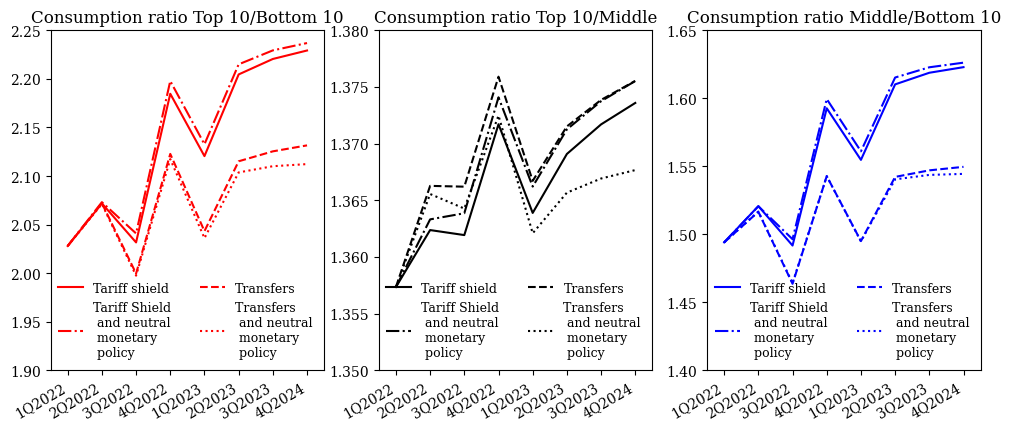

In [181]:
print('------ Figure 9: Inequalities (monetary policy) ------')
lab_dates = ['1Q2022', '2Q2022', '3Q2022', '4Q2022', '1Q2023', '2Q2023', '3Q2023', '4Q2024']
labs = ['Tariff shield', 'Tariff Shield \n and neutral \n monetary \n policy','Transfers','Transfers \n and neutral \n monetary \n policy']
lab_titles = ['Consumption ratio Top 10/Bottom 10', 'Consumption ratio Top 10/Middle', 'Consumption ratio Middle/Bottom 10']

fig = plt.figure(figsize=(12,5))
ax = plt.subplot(131)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6],label=labs[0])
plt.plot(lab_dates,
         (built_C_5_monetneutral[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_monetneutral[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle='-.',label=labs[1])
plt.plot(lab_dates, 
         (built_C_5_conso_b30[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_conso_b30[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle='--', label=labs[2])
plt.plot(lab_dates,
         (built_C_5_conso_b30_monetneutral[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_1_conso_b30_monetneutral[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[6], linestyle=':',label=labs[3])
ax.legend(ncol=2,loc='lower center', frameon=False, fontsize=9)
plt.title(lab_titles[0])
plt.axis([-0.5, 7.5, 1.9, 2.25])
ax = plt.subplot(132)
plt.plot(lab_dates,
         (built_C_5[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3],label=labs[0])
plt.plot(lab_dates, 
         (built_C_5_monetneutral[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_monetneutral[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle='-.',label=labs[1])
plt.plot(lab_dates, 
         (built_C_5_conso_b30[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_conso_b30[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle='--', label=labs[2])
plt.plot(lab_dates, 
         (built_C_5_conso_b30_monetneutral[9:17]+stats_prod['Consumption'].iloc[5])/(built_C_3_conso_b30_monetneutral[9:17]+stats_prod['Consumption'].iloc[3]), 
         color=colors[3], linestyle=':',label=labs[3])
ax.legend(ncol=2,loc='lower center', frameon=False, fontsize=9)
plt.title(lab_titles[1])
plt.axis([-0.5, 7.5, 1.35, 1.38])
ax = plt.subplot(133)
plt.plot(lab_dates, 
         (built_C_3[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0],label=labs[0])
plt.plot(lab_dates, 
         (built_C_3_monetneutral[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_monetneutral[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle='-.', label=labs[1])
plt.plot(lab_dates, 
         (built_C_3_conso_b30[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_conso_b30[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle='--', label=labs[2])
plt.plot(lab_dates, 
         (built_C_3_conso_b30_monetneutral[9:17]+stats_prod['Consumption'].iloc[3])/(built_C_1_conso_b30_monetneutral[9:17]+stats_prod['Consumption'].iloc[1]), 
         color=colors[0], linestyle=':', label=labs[3])
ax.legend(ncol=2,loc='lower center', frameon=False, fontsize=9)
plt.title(lab_titles[2])
plt.axis([-0.5, 7.5, 1.4, 1.65])
fig.autofmt_xdate() 
if save_fig:
    plt.savefig('Figures/Figure9.eps', dpi=600)
plt.show()

<a id="9-GE"></a> 

## 8 General equilibrium effects

In [182]:
_, G_recon, _, _ = build_impulses(G_estim, inputs, ['Recettes', 'Dep', 'Trans', 'B'], Tobs, inputs_info)
new_M  = fcst.generate_M(inputs, ['Recettes', 'Dep', 'Trans', 'B'], sigmas, rhos, Tobs, G_recon)
new_Ds = fcst.reconstruct(new_M, eps_hat_est)
new_Ds_nosubv = fcst.reconstruct(new_M, np.array(eps_hat_est_nosubv))

In [183]:
for (i, elem) in enumerate(['Recettes', 'Dep', 'Trans', 'B']):
    globals()['built_%s' % elem] = new_Ds[:, i, :].sum(axis=1)
    globals()['built_%s_nosubv' % elem] = new_Ds_nosubv[:, i, :].sum(axis=1)

In [184]:
current_B_FL    = (built_B + ss['B'])[0]
current_B_GE_FL = current_B_FL
B_path_GE_FL    = [current_B_GE_FL]             # Total GE
current_B_1_FL  = current_B_FL
B_path_1_FL     = [current_B_1_FL]              # Take only the cost of tariff shield into account
current_B_2_FL  = current_B_FL
B_path_2_FL     = [current_B_2_FL]
current_B_3_FL  = current_B_FL
B_path_3_FL     = [current_B_3_FL]


for i in range(1, 33):
    current_B_GE_FL = (1 + built_r[i] + ss['r']) * current_B_GE_FL - (built_Recettes[i] + ss['Recettes']) + (built_Dep[i] + ss['Dep']) + (built_Trans[i] + ss['Trans'])
    B_path_GE_FL.append(current_B_GE_FL)
    
    current_B_1_FL = (1 + built_r_nosubv[i] + ss['r']) * current_B_1_FL - (built_Recettes_nosubv[i] + ss['Recettes']) + (built_Dep_nosubv[i] + ss['Dep']) + (built_Trans_nosubv[i] + ss['Trans'])
    B_path_1_FL.append(current_B_1_FL)
    
    current_B_2_FL = (1 + built_r_nosubv[i] + ss['r']) * current_B_2_FL - (built_Recettes[i] + ss['Recettes']) + (built_Dep[i] + ss['Dep']) + (built_Trans[i] + ss['Trans'])
    B_path_2_FL.append(current_B_2_FL)

    current_B_3_FL = (1 + built_r_nosubv[i] + ss['r']) * current_B_3_FL - (built_Recettes_nosubv[i] + ss['Recettes']) + (built_Dep[i] + ss['Dep']) + (built_Trans_nosubv[i] + ss['Trans'])
    B_path_3_FL.append(current_B_3_FL)


------ Figure 5: General equilibrium effects ------


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


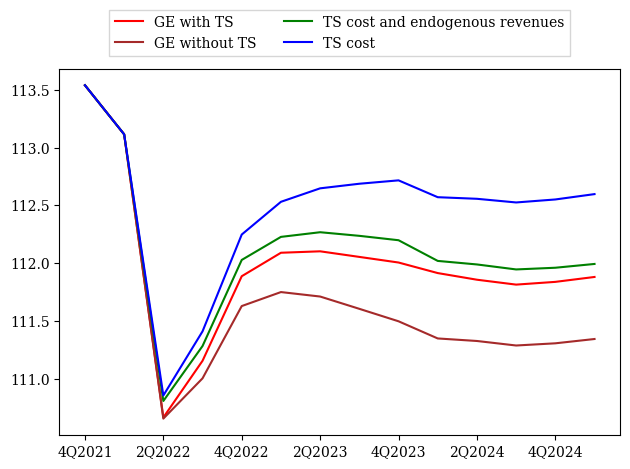

In [185]:
# Figure 5
print('------ Figure 5: General equilibrium effects ------')
xlabels_graph = ['4Q2021', '1Q2022', '2Q2022', '3Q2022', '4Q2022', '1Q2023', '2Q2023', '3Q2023', '4Q2023', '1Q2024', '2Q2024', '3Q2024', '4Q2024', '1Q2025']
debt_ratio_GE_FL = 100 * np.array(B_path_GE_FL) / (built_Y + ss['Y']) / 4
plt.plot(xlabels_graph, debt_ratio_GE_FL[8:22], color='red',label='GE with TS')

debt_ratio_1_FL = 100 * np.array(B_path_1_FL) / (built_Y_nosubv + ss['Y'])/ 4
plt.plot(xlabels_graph, debt_ratio_1_FL[8:22],  color='brown', label='GE without TS')

debt_ratio_2_FL = 100 * np.array(B_path_2_FL) / (built_Y_nosubv + ss['Y']) / 4
plt.plot(xlabels_graph, debt_ratio_2_FL[8:22],  color='green', label='TS cost and endogenous revenues')

debt_ratio_3_FL = 100 * np.array(B_path_3_FL) / (built_Y_nosubv + ss['Y']) / 4
plt.plot(xlabels_graph, debt_ratio_3_FL[8:22],  color='blue', label='TS cost')

plt.xticks(ticks=range(0, len(xlabels_graph), 2), labels=xlabels_graph[::2])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18),
          ncol=2, fancybox=False, shadow=False)
plt.tight_layout()
plt.savefig('Figures/Figure5.eps', dpi=500)
plt.show()